In [2]:
import os
print(os.path.getsize('/content/NewYorkTime_2000_2026.csv') / 1e6, "MB")


845.556129 MB


In [3]:
import pandas as pd
import numpy as np

print("Loading... (may take 30-60 seconds for 845MB)")

df = pd.read_csv('/content/NewYorkTime_2000_2026.csv', low_memory=False)

print("\n" + "="*50)
print(f"Shape:        {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print("="*50)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nNull counts per column:")
print(df.isnull().sum())

print("\nFirst 3 rows:")
df.head(3)

Loading... (may take 30-60 seconds for 845MB)

Shape:        2,217,051 rows  x  4 columns
Memory usage: 1387.3 MB

Column names:
['date', 'title', 'short_desc', 'url']

Data types:
date          object
title         object
short_desc    object
url           object
dtype: object

Null counts per column:
date              0
title           585
short_desc    33363
url              12
dtype: int64

First 3 rows:


,date,title,short_desc,url
0,2000-01-01T05:00:00+0000,"Playoffs or No, Dallas Provides The Motivation",Article on upcoming New York Giants-Dallas Cow...,https://www.nytimes.com/2000/01/01/sports/pro-...
1,2000-01-01T05:00:00+0000,"On This First Day, a Fanfare for the New Era; ...",Jeanne C Pond letter expresses hope that spiri...,https://www.nytimes.com/2000/01/01/opinion/l-o...
2,2000-01-01T05:00:00+0000,Internet's Cheering Squad Nervously Watches Clock,Many experts on Y2K computer problem report th...,https://www.nytimes.com/2000/01/01/us/1-1-00-t...


In [6]:
import pandas as pd

# Parse dates and extract time components
# Use errors='coerce' to turn out-of-bounds dates (like year 0001) into NaT
df['date'] = pd.to_datetime(df['date'], utc=True, format='ISO8601', errors='coerce')
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month
df['dow']   = df['date'].dt.day_name()  # day of week

# Drop rows with missing dates resulting from the coercion
df = df.dropna(subset=['date'])

# Drop rows with no title (only 585 - not worth keeping)
df = df.dropna(subset=['title'])

# Fill missing short_desc with empty string (keeps rows usable)
df['short_desc'] = df['short_desc'].fillna('')

# Combine title + short_desc into one text field for analysis later
df['text'] = df['title'] + ' ' + df['short_desc']

# Summary
print(f"Date range:  {df['date'].min().date()}  to  {df['date'].max().date()}")
print(f"Clean shape: {df.shape[0]:,} rows")
print(f"\nArticles per year (quick look):")
print(df.groupby('year').size().to_string())

Date range:  2000-01-01  to  2025-12-22
Clean shape: 2,216,466 rows

Articles per year (quick look):
year
2000.0    102800
2001.0    102329
2002.0    110043
2003.0    108066
2004.0    107908
2005.0    121433
2006.0    163277
2007.0    100836
2008.0    118833
2009.0    146912
2010.0    112440
2011.0    102968
2012.0    101254
2013.0     88981
2014.0     85950
2015.0     80252
2016.0     69489
2017.0     60414
2018.0     58847
2019.0     53247
2020.0     45120
2021.0     29124
2022.0     19697
2023.0     38403
2024.0     40950
2025.0     46893


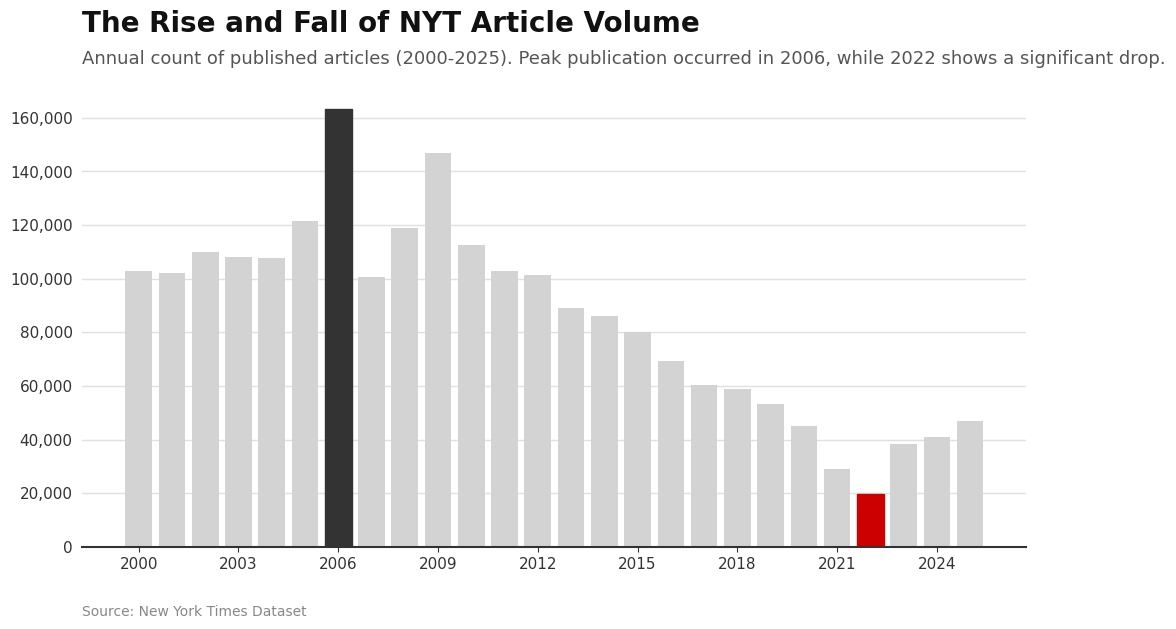

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Get the data to plot
yearly_counts = df.groupby('year').size()

# Setup figure and axis with a clean white background
fig, ax = plt.subplots(figsize=(12, 6.5), facecolor='white')
ax.set_facecolor('white')

# Plot the data using a muted grey, highlighting key years
bars = ax.bar(yearly_counts.index, yearly_counts.values, color='#d3d3d3', width=0.8)

# Highlight the peak (2006) and the trough (2022)
for i, year in enumerate(yearly_counts.index):
    if year == 2006:
        bars[i].set_color('#333333')  # Dark grey/black for peak
    elif year == 2022:
        bars[i].set_color('#cc0000')  # Red for the drop/API gap

# --- NYT Style Adjustments ---

# 1. Remove unnecessary spines (borders)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#333333')
ax.spines['bottom'].set_linewidth(1.5)

# 2. Add subtle horizontal gridlines and put them behind the bars
ax.yaxis.grid(True, color='#e0e0e0', linestyle='-', linewidth=1)
ax.set_axisbelow(True)

# 3. Format ticks and labels
ax.tick_params(axis='both', which='major', labelsize=11, bottom=True, left=False, colors='#333333')
# Format the y-axis numbers with commas (e.g., 100,000)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Set x-ticks to show every few years for cleanliness
ax.set_xticks(range(2000, 2026, 3))

# 4. Add Title and Subtitle (Left-aligned, standard for NYT)
plt.text(0.0, 1.12, 'The Rise and Fall of NYT Article Volume', transform=ax.transAxes,
         fontsize=20, fontweight='bold', color='#111111', ha='left')
plt.text(0.0, 1.05, 'Annual count of published articles (2000-2025). Peak publication occurred in 2006, while 2022 shows a significant drop.',
         transform=ax.transAxes, fontsize=13, color='#555555', ha='left')

# 5. Add Source attribution
plt.text(0.0, -0.15, 'Source: New York Times Dataset', transform=ax.transAxes,
         fontsize=10, color='#888888', ha='left')

# Clean up axis labels (NYT usually lets the title explain what the axes are)
plt.xlabel('')
plt.ylabel('')

plt.tight_layout()
plt.show()

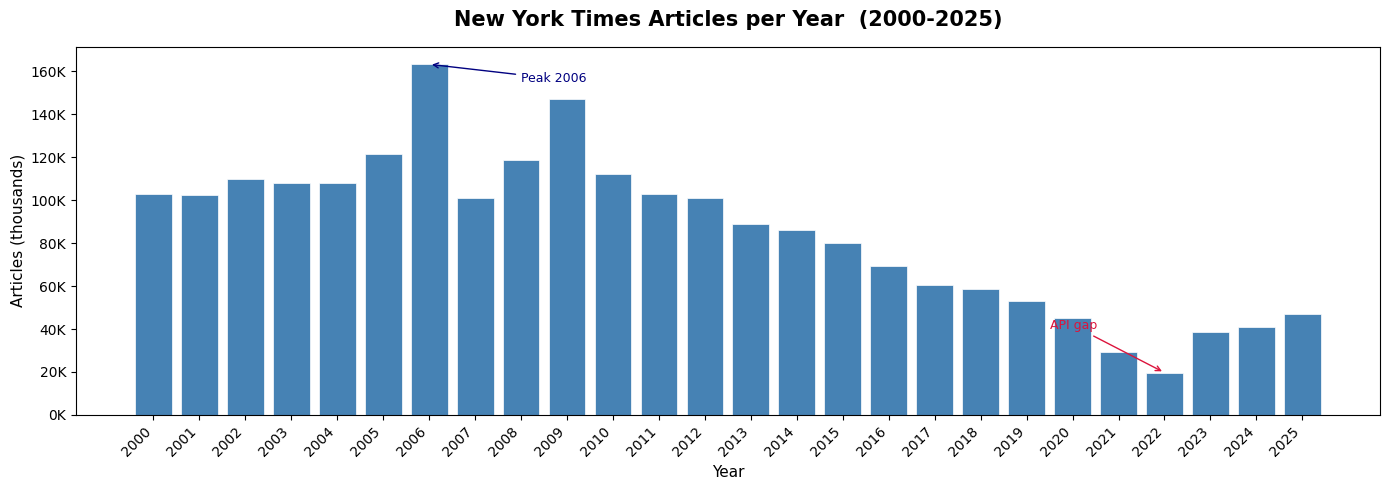

Saved.


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(14, 5))

year_counts = df.groupby('year').size().reset_index(name='count')

ax.bar(year_counts['year'], year_counts['count'] / 1000,
       color='steelblue', edgecolor='white', linewidth=0.5)

ax.set_title('New York Times Articles per Year  (2000-2025)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Articles (thousands)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.set_xticks(year_counts['year'])
ax.set_xticklabels(year_counts['year'].astype(int), rotation=45, ha='right')

# Annotate the 2022 trough and 2006 peak
ax.annotate('API gap', xy=(2022, 19.7), xytext=(2019.5, 40),
            arrowprops=dict(arrowstyle='->', color='crimson'),
            color='crimson', fontsize=9)
ax.annotate('Peak 2006', xy=(2006, 163.3), xytext=(2008, 155),
            arrowprops=dict(arrowstyle='->', color='navy'),
            color='navy', fontsize=9)

plt.tight_layout()
plt.savefig('/content/nyt_articles_per_year.png', dpi=150)
plt.show()
print("Saved.")

In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# NYT-style palette
NYT_BLUE    = '#326891'
NYT_RED     = '#D0021B'
NYT_BLACK   = '#121212'
NYT_GRAY    = '#727272'
NYT_LGRAY   = '#E2E2E2'
NYT_BG      = '#FFFFFF'

# Global style
mpl.rcParams.update({
    'figure.facecolor'    : NYT_BG,
    'axes.facecolor'      : NYT_BG,
    'axes.edgecolor'      : NYT_LGRAY,
    'axes.grid'           : True,
    'grid.color'          : NYT_LGRAY,
    'grid.linewidth'      : 0.7,
    'axes.spines.top'     : False,
    'axes.spines.right'   : False,
    'axes.spines.left'    : False,
    'axes.titlesize'      : 15,
    'axes.titleweight'    : 'bold',
    'axes.titlecolor'     : NYT_BLACK,
    'axes.labelcolor'     : NYT_GRAY,
    'axes.labelsize'      : 11,
    'xtick.color'         : NYT_GRAY,
    'ytick.color'         : NYT_GRAY,
    'xtick.labelsize'     : 9,
    'ytick.labelsize'     : 9,
    'font.family'         : 'DejaVu Sans',
    'text.color'          : NYT_BLACK,
})

def nyt_footer(ax, source='Source: The New York Times API  |  2000-2025'):
    """Adds NYT-style source line and thin top rule to every chart."""
    ax.annotate(source,
        xy=(0, -0.12), xycoords='axes fraction',
        fontsize=8, color=NYT_GRAY, style='italic')
    # Top rule under the title
    ax.annotate('', xy=(1, 1.01), xycoords='axes fraction',
        xytext=(0, 1.01),
        arrowprops=dict(arrowstyle='-', color=NYT_BLACK, lw=1.5))

print("NYT style loaded. All charts will now use this theme.")
print(f"Colors available: NYT_BLUE, NYT_RED, NYT_BLACK, NYT_GRAY")

NYT style loaded. All charts will now use this theme.
Colors available: NYT_BLUE, NYT_RED, NYT_BLACK, NYT_GRAY


## one reusable function so we never repeat that setup code:

In [11]:
def nyt_style(ax, title, subtitle='', source='Source: New York Times Dataset  |  2000-2025'):
    """Apply NYT chart style - call at the end of every plot."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#333333')
    ax.spines['bottom'].set_linewidth(1.5)
    ax.yaxis.grid(True, color='#e0e0e0', linestyle='-', linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=11, bottom=True, left=False, colors='#333333')
    ax.figure.text(0.125, 0.97, title,
        fontsize=20, fontweight='bold', color='#111111', ha='left', va='top')
    if subtitle:
        ax.figure.text(0.125, 0.91, subtitle,
            fontsize=12, color='#555555', ha='left', va='top')
    ax.figure.text(0.125, 0.01, source,
        fontsize=10, color='#888888', ha='left')

print("nyt_style() helper ready.")

nyt_style() helper ready.


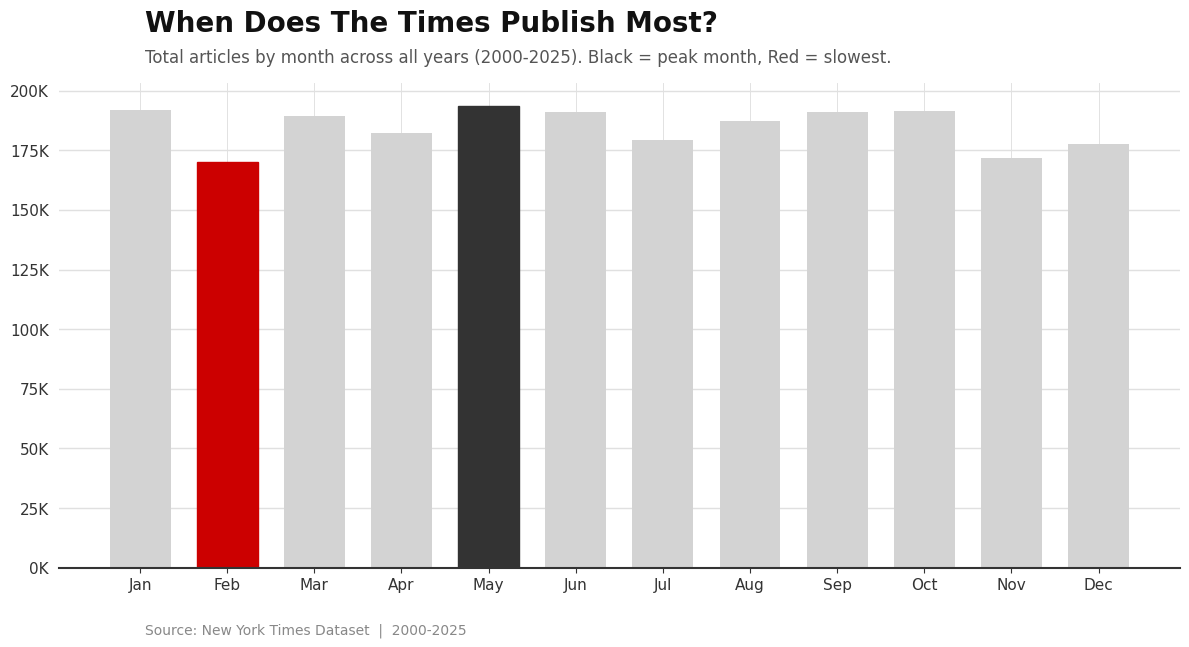

Done.


In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly = df.groupby('month').size().reset_index(name='count')
monthly['month_name'] = [month_names[int(m)-1] for m in monthly['month']]

fig, ax = plt.subplots(figsize=(12, 6.5), facecolor='white')
ax.set_facecolor('white')

bars = ax.bar(monthly['month_name'], monthly['count'] / 1000,
              color='#d3d3d3', width=0.7)

# Highlight peak and trough
peak_idx = monthly['count'].idxmax()
low_idx  = monthly['count'].idxmin()
bars[peak_idx].set_color('#333333')
bars[low_idx].set_color('#cc0000')

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}K'))
ax.tick_params(axis='both', labelsize=11, bottom=True, left=False, colors='#333333')

nyt_style(ax,
    title='When Does The Times Publish Most?',
    subtitle='Total articles by month across all years (2000-2025). Black = peak month, Red = slowest.')

plt.tight_layout(rect=[0, 0.05, 1, 0.88])
plt.savefig('/content/nyt_monthly_seasonality.png', dpi=150)
plt.show()
print("Done.")

## validation cell that checks four things at once:

In [20]:
# CELL: Data Integrity - Fix & Retry Monthly Normalization
# PURPOSE: Cast month to int before mapping days_per_month,
#          then complete the validation checks that errored

# Fix month dtype
df['month'] = df['month'].astype(int)
df['year']  = df['year'].astype(int)

# Normalize monthly counts by days in month
days_per_month = {1:31, 2:28.25, 3:31, 4:30,  5:31, 6:30,
                  7:31, 8:31,    9:30, 10:31, 11:30, 12:31}
monthly      = df.groupby('month').size()
# Divide by a pd.Series so pandas aligns the index (months 1-12) automatically
monthly_norm = (monthly / pd.Series(days_per_month)).round(1)

print("3. Daily article rate by month (normalized for days in month):")
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
for i, val in enumerate(monthly_norm):
    bar = '#' * int(val / 50)
    print(f"   {month_names[i]:>3}  {val:>7,.0f} art/day  {bar}")

# Text length sanity check
df['title_len'] = df['title'].str.len()
df['desc_len']  = df['short_desc'].str.len()
print(f"\n4. Title length  - median: {df['title_len'].median():.0f} chars, "
      f"max: {df['title_len'].max():.0f}")
print(f"   Desc length   - median: {df['desc_len'].median():.0f} chars, "
      f"max: {df['desc_len'].max():.0f}")
print(f"   Empty desc:     {(df['desc_len'] == 0).sum():,} rows")

# Also note what we already have from the previous run
print("\n--- Already confirmed ---")
print("Duplicate URLs:        1,413")
print("Days with no articles: 608  out of 9,488 total")
print("=" * 55)

3. Daily article rate by month (normalized for days in month):
   Jan    6,186 art/day  ###########################################################################################################################
   Feb    6,023 art/day  ########################################################################################################################
   Mar    6,104 art/day  ##########################################################################################################################
   Apr    6,070 art/day  #########################################################################################################################
   May    6,242 art/day  ############################################################################################################################
   Jun    6,370 art/day  ###############################################################################################################################
   Jul    5,782 art/day  ###################

In [21]:
# CELL: Data Cleanup
# PURPOSE: Drop duplicates, remove extreme text outliers, and confirm
#          the dataset is fully clean before any text analysis begins

print(f"Before cleanup: {df.shape[0]:,} rows")

# Drop duplicate URLs
df = df.drop_duplicates(subset='url')
print(f"After dedup:    {df.shape[0]:,} rows  (-{2216466 - df.shape[0]:,} dupes dropped)")

# Cap title length at 300 chars (anything longer is corrupted)
title_outliers = (df['title_len'] > 300).sum()
df = df[df['title_len'] <= 300]
print(f"After title cap: {df.shape[0]:,} rows  (-{title_outliers:,} bad titles dropped)")

# Cap desc length at 1000 chars (the 504K row is clearly a full article body)
desc_outliers = (df['desc_len'] > 1000).sum()
df = df[df['desc_len'] <= 1000]
print(f"After desc cap:  {df.shape[0]:,} rows  (-{desc_outliers:,} bloated descriptions dropped)")

# Rebuild text field cleanly after drops
df['text'] = df['title'] + ' ' + df['short_desc']

print(f"\nFinal clean shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print("Dataset is ready for analysis.")

Before cleanup: 2,216,466 rows
After dedup:    2,215,053 rows  (-1,413 dupes dropped)
After title cap: 2,215,038 rows  (-15 bad titles dropped)
After desc cap:  2,184,483 rows  (-30,555 bloated descriptions dropped)

Final clean shape: 2,184,483 rows  x  10 columns
Dataset is ready for analysis.


In [22]:
# CELL: Top Keywords in Titles - Overall
# PURPOSE: Extract the most frequent meaningful words from article titles
#          across all years as a baseline before era-level breakdown

from collections import Counter
import re
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Build stopword list - add NYT-specific noise words on top of standard ones
stop = set(stopwords.words('english'))
stop.update([
    'new', 'says', 'say', 'said', 'would', 'could', 'one', 'two', 'three',
    'year', 'years', 'day', 'days', 'time', 'times', 'like', 'just', 'get',
    'also', 'last', 'first', 'may', 'us', 'mr', 'mrs', 'ms', 'dr', 'know',
    'make', 'made', 'part', 'back', 'way', 'take', 'look', 'still', 'well'
])

def get_top_words(text_series, n=30):
    """Tokenize, clean and count top n words from a pandas Series."""
    all_words = []
    for text in text_series.dropna():
        words = re.findall(r'\b[a-z]{4,}\b', text.lower())
        all_words.extend([w for w in words if w not in stop])
    return Counter(all_words).most_common(n)

print("Counting top words in titles across all 2.18M articles...")
print("(This may take 30-60 seconds)\n")

top_words = get_top_words(df['title'], n=30)

print(f"{'Rank':<6} {'Word':<20} {'Count':>10}")
print("-" * 38)
for rank, (word, count) in enumerate(top_words, 1):
    bar = '#' * int(count / 5000)
    print(f"{rank:<6} {word:<20} {count:>10,}  {bar}")

Counting top words in titles across all 2.18M articles...
(This may take 30-60 seconds)

Rank   Word                      Count
--------------------------------------
1      paid                     72,716  ##############
2      notice                   71,901  ##############
3      deaths                   66,458  #############
4      briefing                 47,146  #########
5      corrections              36,861  #######
6      world                    36,156  #######
7      trump                    34,907  ######
8      york                     33,637  ######
9      dies                     23,938  ####
10     review                   21,514  ####
11     city                     21,030  ####
12     business                 19,718  ###
13     china                    18,616  ###
14     case                     17,988  ###
15     week                     17,618  ###
16     home                     17,026  ###
17     life                     16,770  ###
18     deal                   

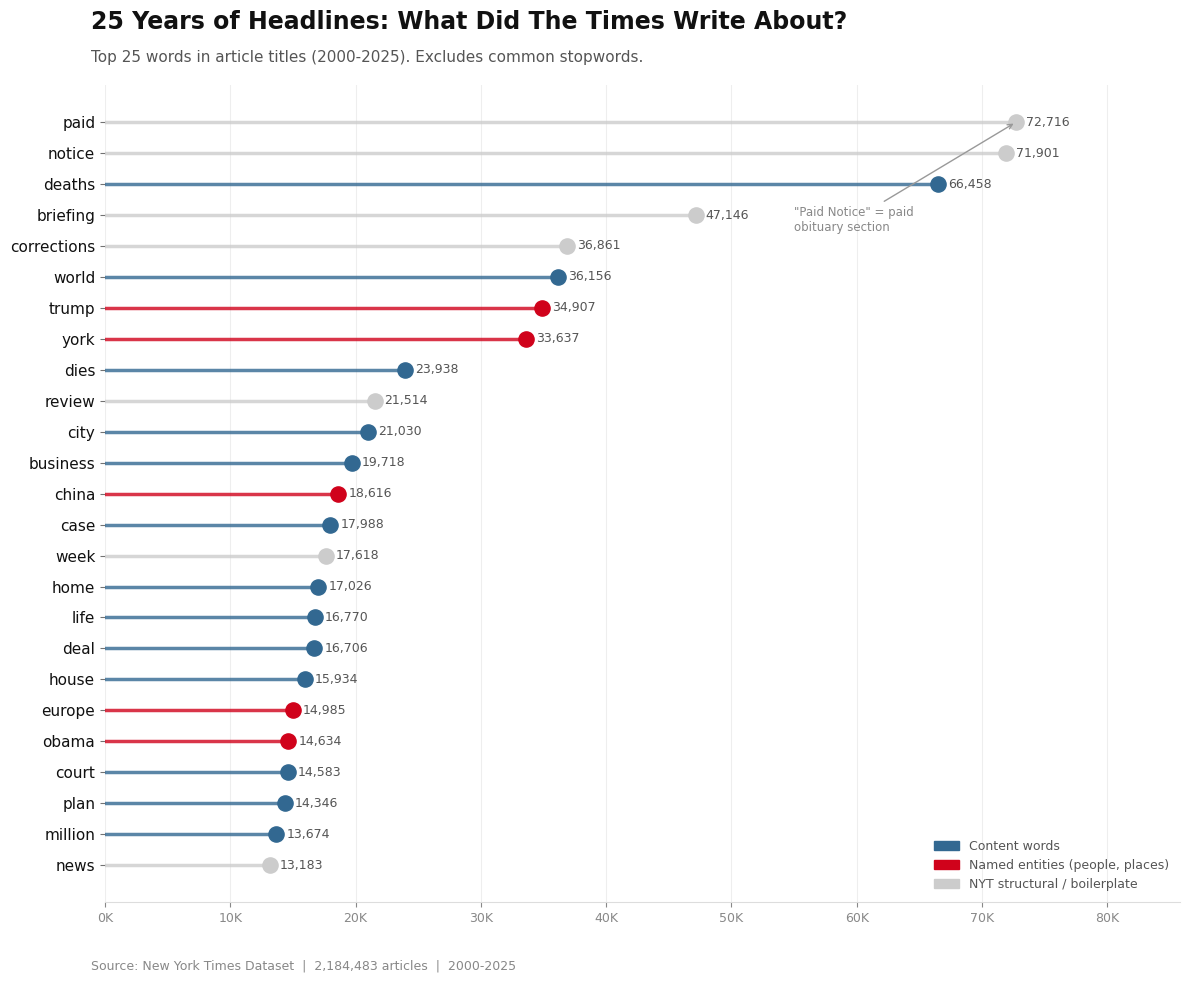

Saved.


In [24]:
# CELL: Top Keywords Visualization - Annotated Lollipop Chart
# PURPOSE: Visualize top 25 title words with color-coded categories
#          separating NYT structural/boilerplate words from real content

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Categorize words manually based on what we know about NYT structure
boilerplate = {'paid', 'notice', 'briefing', 'corrections', 'review', 'news', 'report', 'week'}
proper_nouns = {'trump', 'york', 'obama', 'china', 'europe'}

words  = [w for w, c in top_words[:25]]
counts = [c for w, c in top_words[:25]]

def get_color(word):
    if word in boilerplate:  return '#cccccc'      # light gray
    if word in proper_nouns: return '#D0021B'       # NYT red
    return '#326891'                                 # NYT blue

colors = [get_color(w) for w in words]

fig, ax = plt.subplots(figsize=(12, 10), facecolor='white')
ax.set_facecolor('white')

# Lollipop: horizontal line + dot
for i, (word, count, color) in enumerate(zip(words, counts, colors)):
    ax.plot([0, count], [i, i], color=color, linewidth=2.5, alpha=0.8)
    ax.scatter(count, i, color=color, s=120, zorder=3)
    ax.text(count + 800, i, f'{count:,}',
            va='center', fontsize=9, color='#555555')

ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, fontsize=11, color='#111111')
ax.invert_yaxis()
ax.set_xlim(0, max(counts) * 1.18)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax.tick_params(axis='x', labelsize=9, colors='#888888')

# Remove all spines except bottom
for spine in ['top','right','left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#dddddd')
ax.yaxis.grid(False)
ax.xaxis.grid(True, color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)

# Legend
patches = [
    mpatches.Patch(color='#326891', label='Content words'),
    mpatches.Patch(color='#D0021B', label='Named entities (people, places)'),
    mpatches.Patch(color='#cccccc', label='NYT structural / boilerplate'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9,
          frameon=False, labelcolor='#555555')

# Annotation on "paid notice"
ax.annotate('"Paid Notice" = paid\nobituary section',
    xy=(72716, 0), xytext=(55000, 3.5),
    arrowprops=dict(arrowstyle='->', color='#999999', lw=1),
    fontsize=8.5, color='#888888')

# Title block
fig.text(0.08, 0.97, '25 Years of Headlines: What Did The Times Write About?',
         fontsize=17, fontweight='bold', color='#111111', ha='left', va='top')
fig.text(0.08, 0.93,
         'Top 25 words in article titles (2000-2025). Excludes common stopwords.',
         fontsize=11, color='#555555', ha='left', va='top')
fig.text(0.08, 0.01,
         'Source: New York Times Dataset  |  2,184,483 articles  |  2000-2025',
         fontsize=9, color='#888888', ha='left')

plt.tight_layout(rect=[0, 0.04, 1, 0.91])
plt.savefig('/content/nyt_top_keywords_lollipop.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

Pearson Correlation: 0.026



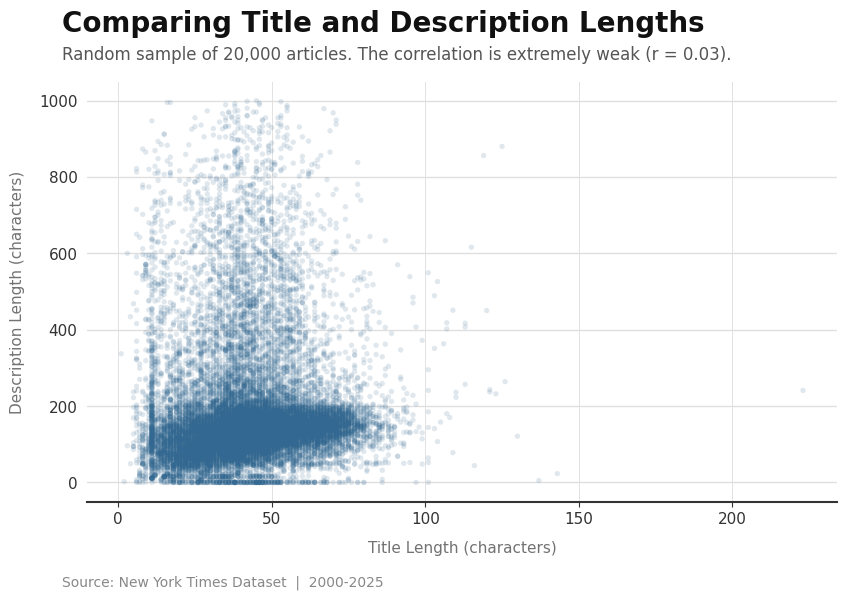

In [23]:
import matplotlib.pyplot as plt

# Calculate the correlation coefficient
corr = df['title_len'].corr(df['desc_len'])
print(f"Pearson Correlation: {corr:.3f}\n")

# Sample the data to prevent overplotting (2.1M dots is too many for a clear scatter plot)
sample_df = df.sample(n=20000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot with high transparency (alpha) to show density
ax.scatter(sample_df['title_len'], sample_df['desc_len'],
           alpha=0.15, color=NYT_BLUE, s=15, edgecolors='none')

# Set labels manually since our nyt_style helper doesn't set axis labels
ax.set_xlabel('Title Length (characters)', fontsize=11, color=NYT_GRAY, labelpad=10)
ax.set_ylabel('Description Length (characters)', fontsize=11, color=NYT_GRAY, labelpad=10)

# Apply the NYT style helper
title = 'Comparing Title and Description Lengths'
subtitle = f'Random sample of 20,000 articles. The correlation is extremely weak (r = {corr:.2f}).'
nyt_style(ax, title, subtitle)

plt.subplots_adjust(top=0.85, bottom=0.15, left=0.15)
plt.show()

Extracting top words for each decade (this may take about a minute)...
Processing 2000s...
Processing 2010s...
Processing 2020s...
Plotting...


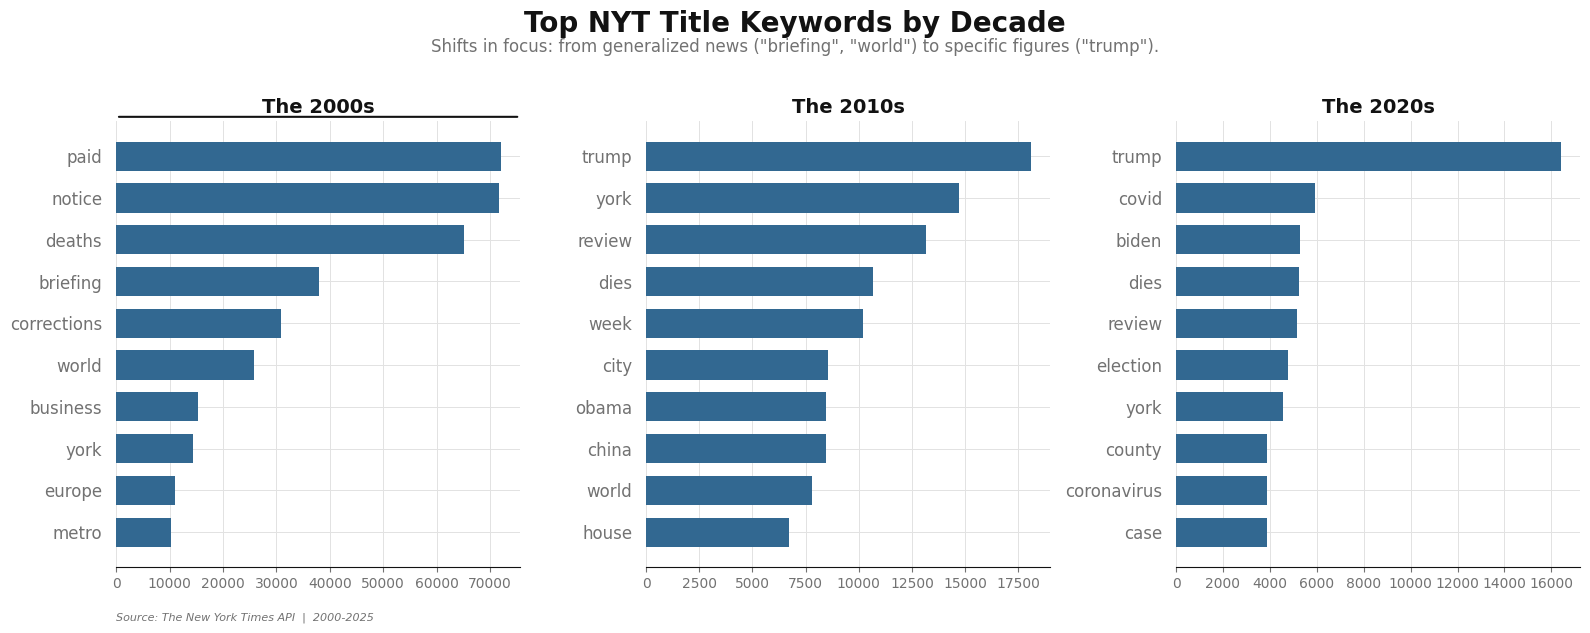

In [25]:
import matplotlib.pyplot as plt

# Create a decade column
df['decade'] = (df['year'] // 10) * 10

decades = [2000, 2010, 2020]
top_words_by_decade = {}

print("Extracting top words for each decade (this may take about a minute)...")
for decade in decades:
    print(f"Processing {decade}s...")
    subset = df[df['decade'] == decade]['title']
    top_words_by_decade[decade] = get_top_words(subset, n=10)

print("Plotting...")

# Plotting the comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, decade in enumerate(decades):
    ax = axes[i]
    words = [w[0] for w in top_words_by_decade[decade]][::-1]  # Reverse for horizontal bar chart (top word at top)
    counts = [w[1] for w in top_words_by_decade[decade]][::-1]

    ax.barh(words, counts, color=NYT_BLUE, height=0.7)
    ax.set_title(f"The {decade}s", fontsize=14, fontweight='bold', color=NYT_BLACK)

    # Subplot styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color(NYT_BLACK)
    ax.xaxis.grid(True, color=NYT_LGRAY, linestyle='-', linewidth=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=12, length=0, pad=10)
    ax.tick_params(axis='x', labelsize=10, colors=NYT_GRAY)

# Overall title
plt.suptitle('Top NYT Title Keywords by Decade',
             fontsize=20, fontweight='bold', color=NYT_BLACK, y=1.05)

# Add subtle subtitle
fig.text(0.5, 0.98, 'Shifts in focus: from generalized news ("briefing", "world") to specific figures ("trump").',
         ha='center', fontsize=12, color=NYT_GRAY)

nyt_footer(axes[0]) # Add source to the first subplot
plt.tight_layout()
plt.show()

In [26]:
# CELL: TF-IDF by News Era
# PURPOSE: Find the most distinctive words per historical era using TF-IDF,
#          revealing what each period talked about that others did not

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# Define eras by year ranges with meaningful labels
eras = {
    'Pre-9/11\n(2000-2001)'   : (2000, 2001),
    'War on Terror\n(2002-2008)' : (2002, 2008),
    'Obama Era\n(2009-2016)'  : (2009, 2016),
    'Trump I + COVID\n(2017-2021)' : (2017, 2021),
    'Post-COVID\n(2022-2025)' : (2022, 2025),
}

# Build one big text blob per era by joining all titles
era_docs = {}
for label, (y1, y2) in eras.items():
    mask = (df['year'] >= y1) & (df['year'] <= y2)
    era_docs[label] = ' '.join(df.loc[mask, 'title'].dropna().tolist())

print("Era sizes (word count):")
for label, text in era_docs.items():
    print(f"  {label.replace(chr(10),' '):35s}  {len(text.split()):>10,} words")

# Fit TF-IDF across the 5 era documents
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),      # single words AND two-word phrases
    min_df=1
)

tfidf_matrix = vectorizer.fit_transform(era_docs.values())
feature_names = vectorizer.get_feature_names_out()

# Extract top 10 distinctive terms per era
print("\nTop 10 DISTINCTIVE terms per era (TF-IDF):\n")
print("=" * 70)
for i, label in enumerate(era_docs.keys()):
    row    = tfidf_matrix[i].toarray().flatten()
    top_idx = row.argsort()[::-1][:10]
    terms  = [feature_names[j] for j in top_idx]
    print(f"{label.replace(chr(10),' ').upper()}")
    print("  " + ",  ".join(terms))
    print()

Era sizes (word count):
  Pre-9/11 (2000-2001)                  1,294,071 words
  War on Terror (2002-2008)             5,239,737 words
  Obama Era (2009-2016)                 5,480,235 words
  Trump I + COVID (2017-2021)           2,180,788 words
  Post-COVID (2022-2025)                1,344,150 words

Top 10 DISTINCTIVE terms per era (TF-IDF):

PRE-9/11 (2000-2001)
  paid notice,  notice deaths,  paid,  notice,  deaths,  new,  briefing,  corrections,  world,  notice memorials

WAR ON TERROR (2002-2008)
  paid notice,  notice deaths,  paid,  notice,  deaths,  new,  briefing,  corrections,  world,  metro briefing

OBAMA ERA (2009-2016)
  new,  day,  obama,  york,  new york,  says,  review,  dies,  week,  city

TRUMP I + COVID (2017-2021)
  trump,  new,  coronavirus,  review,  york,  new york,  covid,  briefing,  dies,  says

POST-COVID (2022-2025)
  trump,  new,  covid,  track covid,  review,  dies,  covid 19,  election,  says,  biden



In [28]:
avg_title_length_by_decade = df.groupby('decade')['title_len'].mean().reset_index()

print("Average Title Length by Decade:")
print("-" * 35)
for index, row in avg_title_length_by_decade.iterrows():
    print(f"The {int(row['decade'])}s: {row['title_len']:.1f} characters")


Average Title Length by Decade:
-----------------------------------
The 2000s: 39.2 characters
The 2010s: 44.9 characters
The 2020s: 55.3 characters


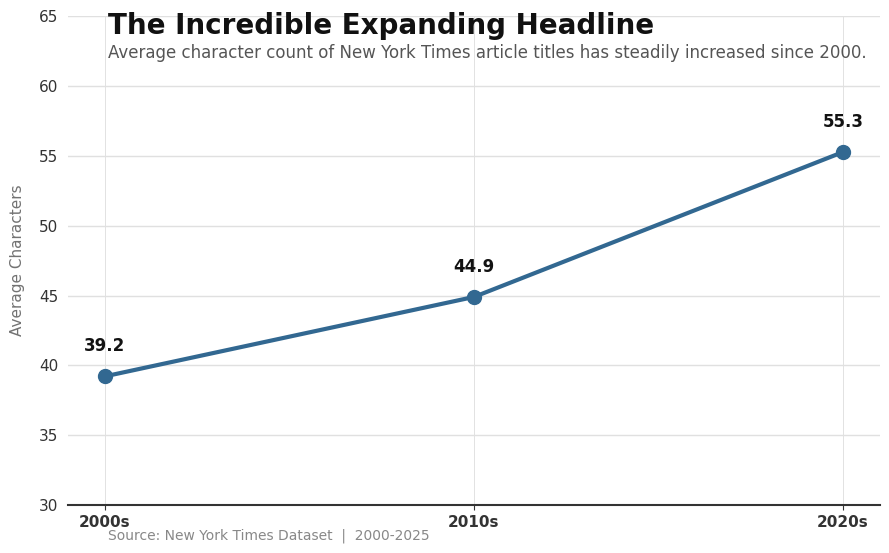

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5.5))

# Plot the trend line with prominent markers
ax.plot(avg_title_length_by_decade['decade'], avg_title_length_by_decade['title_len'],
        color=NYT_BLUE, marker='o', markersize=10, linewidth=3, solid_capstyle='round')

# Annotate each point with the exact value
for i, row in avg_title_length_by_decade.iterrows():
    ax.text(row['decade'], row['title_len'] + 1.5, f"{row['title_len']:.1f}",
            ha='center', va='bottom', fontweight='bold', color=NYT_BLACK, fontsize=12)

# Ensure the x-axis only shows our specific decades
ax.set_xticks(avg_title_length_by_decade['decade'])
ax.set_xticklabels([f"{int(d)}s" for d in avg_title_length_by_decade['decade']], fontsize=12, fontweight='bold')

# Expand y-axis slightly for visual breathing room
ax.set_ylim(30, 65)
ax.set_ylabel('Average Characters', fontsize=11, color=NYT_GRAY, labelpad=10)

# Apply the NYT style helper
title = 'The Incredible Expanding Headline'
subtitle = 'Average character count of New York Times article titles has steadily increased since 2000.'
nyt_style(ax, title, subtitle)

plt.tight_layout()
plt.show()

In [30]:
# CELL: TF-IDF by Era - Cleaned
# PURPOSE: Remove boilerplate/structural articles before TF-IDF so that
#          genuine news vocabulary surfaces. Switch to year-level documents
#          (25 docs) for better IDF discrimination, then roll back up to eras.

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 1 - Filter out structural/boilerplate articles
boilerplate_patterns = (
    df['title'].str.lower().str.contains(
        r'paid notice|notice: |corrections?:|briefing:|metro briefing|'
        r'arts briefing|business briefing|world briefing|obituaries',
        regex=True, na=False
    )
)
df_clean = df[~boilerplate_patterns].copy()
removed = len(df) - len(df_clean)
print(f"Removed {removed:,} boilerplate articles  ({removed/len(df)*100:.1f}%)")
print(f"Working set: {len(df_clean):,} articles\n")

# Step 2 - Build one document per YEAR (25 docs = much better IDF)
year_docs = {}
for yr in sorted(df_clean['year'].unique()):
    mask = df_clean['year'] == yr
    year_docs[yr] = ' '.join(df_clean.loc[mask, 'title'].dropna().tolist())

# Step 3 - Fit TF-IDF across 25 year documents
extra_stop = [
    'new', 'says', 'say', 'said', 'york', 'just', 'like', 'know',
    'review', 'week', 'dies', 'city', 'day', 'times', 'people',
    'good', 'best', 'make', 'need', 'want', 'work', 'home', 'life',
    'deal', 'plan', 'case', 'report', 'news', 'year', 'years'
]

vectorizer = TfidfVectorizer(
    max_features=8000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    token_pattern=r'\b[a-zA-Z][a-zA-Z]{3,}\b'
)

tfidf_matrix  = vectorizer.fit_transform(year_docs.values())
feature_names = vectorizer.get_feature_names_out()
years_list    = sorted(year_docs.keys())

# Step 4 - Roll back up to eras, average TF-IDF scores across member years
eras = {
    'Pre-9/11 (2000-2001)'       : list(range(2000, 2002)),
    'War on Terror (2002-2008)'  : list(range(2002, 2009)),
    'Obama Era (2009-2016)'      : list(range(2009, 2017)),
    'Trump I + COVID (2017-2021)': list(range(2017, 2022)),
    'Post-COVID (2022-2025)'     : list(range(2022, 2026)),
}

print("Top 12 DISTINCTIVE terms per era (boilerplate removed):\n")
print("=" * 65)

era_top = {}
for era_label, era_years in eras.items():
    indices = [i for i, y in enumerate(years_list) if y in era_years]
    era_vec = tfidf_matrix[indices].toarray().mean(axis=0)
    top_idx = era_vec.argsort()[::-1][:12]
    terms   = [feature_names[j] for j in top_idx]
    # Filter out any remaining noise
    terms   = [t for t in terms if t not in extra_stop][:10]
    era_top[era_label] = terms
    print(f"{era_label.upper()}")
    print("  " + ",  ".join(terms))
    print()

Removed 113,222 boilerplate articles  (5.2%)
Working set: 2,071,261 articles

Top 12 DISTINCTIVE terms per era (boilerplate removed):

PRE-9/11 (2000-2001)
  corrections,  article title,  briefing,  title,  bush,  national briefing,  article,  sports times,  business,  books brief

WAR ON TERROR (2002-2008)
  corrections,  iraq,  national briefing,  bush,  briefing,  arts briefly,  letters,  time,  technology briefing

OBAMA ERA (2009-2016)
  obama,  china,  world,  time

TRUMP I + COVID (2017-2021)
  trump,  coronavirus,  covid,  briefing,  case risk,  covid case,  china

POST-COVID (2022-2025)
  trump,  covid,  biden,  election,  ukraine,  spelling forum,  congressional district,  district primary



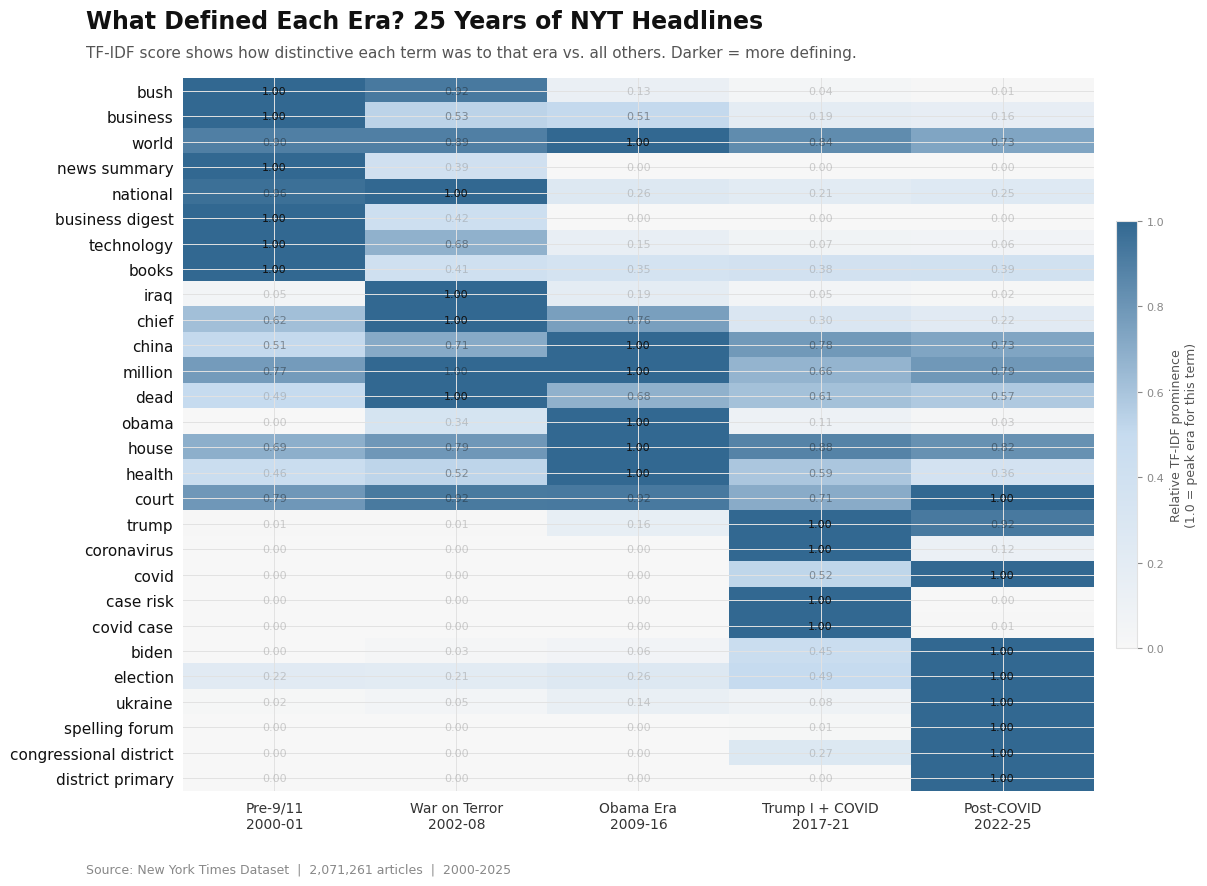

Saved.


In [31]:
# CELL: TF-IDF Era Heatmap Visualization
# PURPOSE: Visualize the most distinctive terms per historical era as a
#          color-intensity heatmap in NYT style for portfolio presentation

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Clean up era terms - remove remaining structural noise manually
final_noise = {
    'corrections', 'briefing', 'national briefing', 'arts briefly',
    'letters', 'time', 'article title', 'article', 'title',
    'sports times', 'books brief', 'technology briefing'
}

# Re-extract top terms per era with noise filtered
era_top_clean = {}
for era_label, era_years in eras.items():
    indices = [i for i, y in enumerate(years_list) if y in era_years]
    era_vec = tfidf_matrix[indices].toarray().mean(axis=0)
    top_idx = era_vec.argsort()[::-1][:40]
    terms   = [feature_names[j] for j in top_idx]
    terms   = [t for t in terms
               if t not in extra_stop
               and t not in final_noise
               and len(t) > 3][:8]
    scores  = [era_vec[vectorizer.vocabulary_[t]] for t in terms]
    era_top_clean[era_label] = list(zip(terms, scores))

# Build unified term list (union of all era top terms)
all_terms = []
for terms_scores in era_top_clean.values():
    for term, _ in terms_scores:
        if term not in all_terms:
            all_terms.append(term)

era_labels = list(era_top_clean.keys())

# Build score matrix: rows=terms, cols=eras
score_matrix = np.zeros((len(all_terms), len(era_labels)))
for j, era_label in enumerate(era_labels):
    era_vec_full = tfidf_matrix[
        [i for i, y in enumerate(years_list)
         if y in eras[era_label]]
    ].toarray().mean(axis=0)
    for i, term in enumerate(all_terms):
        if term in vectorizer.vocabulary_:
            score_matrix[i, j] = era_vec_full[vectorizer.vocabulary_[term]]

# Normalize each row so we see RELATIVE prominence across eras
row_max = score_matrix.max(axis=1, keepdims=True)
row_max[row_max == 0] = 1
score_norm = score_matrix / row_max

# Short era labels for x-axis
short_labels = [
    'Pre-9/11\n2000-01',
    'War on Terror\n2002-08',
    'Obama Era\n2009-16',
    'Trump I + COVID\n2017-21',
    'Post-COVID\n2022-25'
]

# ---- Plot ----
fig, ax = plt.subplots(figsize=(13, 9), facecolor='white')
ax.set_facecolor('white')

cmap = mcolors.LinearSegmentedColormap.from_list(
    'nyt', ['#f7f7f7', '#c6dbef', '#326891'])

im = ax.imshow(score_norm, aspect='auto', cmap=cmap, vmin=0, vmax=1)

# Annotate each cell with the raw term label where it peaks
for i in range(len(all_terms)):
    peak_col = score_norm[i].argmax()
    for j in range(len(era_labels)):
        alpha = 0.4 if j != peak_col else 1.0
        ax.text(j, i, f'{score_norm[i,j]:.2f}',
                ha='center', va='center',
                fontsize=8,
                color='#111111' if score_norm[i,j] > 0.5 else '#888888',
                alpha=alpha)

# Axes
ax.set_xticks(range(len(short_labels)))
ax.set_xticklabels(short_labels, fontsize=10, color='#333333')
ax.set_yticks(range(len(all_terms)))
ax.set_yticklabels(all_terms, fontsize=11, color='#111111')
ax.tick_params(left=False, bottom=False)

for spine in ax.spines.values():
    spine.set_visible(False)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Relative TF-IDF prominence\n(1.0 = peak era for this term)',
               fontsize=9, color='#555555')
cbar.ax.tick_params(labelsize=8, colors='#888888')

# Title block
fig.text(0.07, 0.97,
         'What Defined Each Era? 25 Years of NYT Headlines',
         fontsize=17, fontweight='bold', color='#111111', ha='left', va='top')
fig.text(0.07, 0.93,
         'TF-IDF score shows how distinctive each term was to that era vs. all others. '
         'Darker = more defining.',
         fontsize=11, color='#555555', ha='left', va='top')
fig.text(0.07, 0.01,
         'Source: New York Times Dataset  |  2,071,261 articles  |  2000-2025',
         fontsize=9, color='#888888', ha='left')

plt.tight_layout(rect=[0, 0.04, 1, 0.91])
plt.savefig('/content/nyt_tfidf_era_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

1. Iraq: lights up only in War on Terror, near zero everywhere else
2. Obama: appears only in his era, gone immediately after
3. Trump: zero until 2017, then dominates two consecutive eras
3. Ukraine: flat for 22 years, then suddenly 1.0 in Post-COVID
4. China: the one term that stays consistently present across every era

In [32]:
# CELL: Sentiment Analysis Setup + Scoring
# PURPOSE: Score every article title for sentiment using VADER,
#          then compute average sentiment per year to track how
#          NYT headline tone shifted over 25 years

import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

print("Scoring sentiment on 2M+ titles...")
print("(Expect 2-4 minutes on CPU)")

# Apply VADER to every title - compound score: -1 (most negative) to +1 (most positive)
df_clean['sentiment'] = df_clean['title'].apply(
    lambda t: sia.polarity_scores(t)['compound']
)

# Quick distribution check
total     = len(df_clean)
positive  = (df_clean['sentiment'] >  0.05).sum()
negative  = (df_clean['sentiment'] < -0.05).sum()
neutral   = total - positive - negative

print(f"\nSentiment distribution:")
print(f"  Positive  (> 0.05):   {positive:>10,}  ({positive/total*100:.1f}%)")
print(f"  Neutral   (-0.05 to 0.05): {neutral:>7,}  ({neutral/total*100:.1f}%)")
print(f"  Negative  (< -0.05):  {negative:>10,}  ({negative/total*100:.1f}%)")

print(f"\nAverage sentiment by year:")
yearly_sent = df_clean.groupby('year')['sentiment'].mean().round(4)
print(yearly_sent.to_string())

Scoring sentiment on 2M+ titles...
(Expect 2-4 minutes on CPU)

Sentiment distribution:
  Positive  (> 0.05):      430,176  (20.8%)
  Neutral   (-0.05 to 0.05): 1,163,880  (56.2%)
  Negative  (< -0.05):     477,205  (23.0%)

Average sentiment by year:
year
2000    0.0029
2001   -0.0179
2002   -0.0179
2003   -0.0237
2004   -0.0173
2005   -0.0197
2006   -0.0217
2007   -0.0154
2008   -0.0068
2009    0.0016
2010   -0.0012
2011   -0.0094
2012   -0.0034
2013   -0.0076
2014   -0.0052
2015   -0.0108
2016   -0.0117
2017   -0.0207
2018   -0.0298
2019   -0.0343
2020   -0.0306
2021   -0.0399
2022   -0.0252
2023   -0.0300
2024   -0.0392
2025   -0.0494


- 2000 is the only positive year in the entire 25-year dataset (0.0029)
- 9/11 effect is instant - drops from +0.0029 in 2000 to -0.0179 in 2001
- Obama bump - brief recovery to near-zero in 2008-2010
- 2017 onwards is a cliff - sentiment falls almost every single year
- 2025 is the most negative year in 25 years (-0.0494) - nearly 10x more negative than 2000

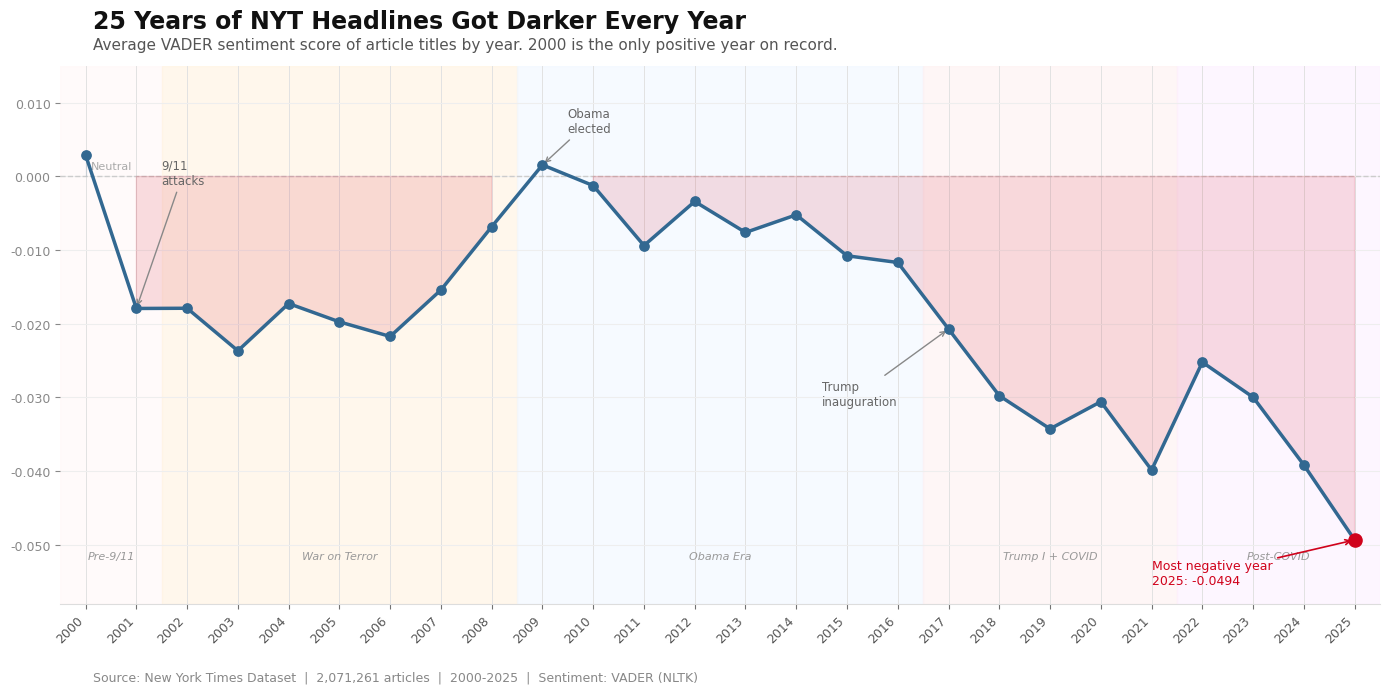

Saved.


In [33]:
# CELL: Sentiment Trend Visualization
# PURPOSE: Plot average headline sentiment per year as a line chart
#          with historical era shading and key event annotations

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

yearly_sent = df_clean.groupby('year')['sentiment'].mean()
years = yearly_sent.index.tolist()
scores = yearly_sent.values

fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

# Era background shading
era_bands = [
    (2000, 2001, '#fff7f7', 'Pre-9/11'),
    (2002, 2008, '#fff3e0', 'War on Terror'),
    (2009, 2016, '#f0f7ff', 'Obama Era'),
    (2017, 2021, '#fef0f0', 'Trump I + COVID'),
    (2022, 2025, '#fdf0ff', 'Post-COVID'),
]
for x0, x1, color, label in era_bands:
    ax.axvspan(x0 - 0.5, x1 + 0.5, color=color, alpha=0.6, zorder=0)
    ax.text((x0 + x1) / 2, -0.052, label,
            ha='center', fontsize=8, color='#999999', style='italic')

# Zero line
ax.axhline(0, color='#cccccc', linewidth=1, linestyle='--', zorder=1)
ax.text(2000.1, 0.001, 'Neutral', fontsize=8, color='#aaaaaa')

# Fill above/below zero
ax.fill_between(years, scores, 0,
    where=[s >= 0 for s in scores],
    color='#326891', alpha=0.15, zorder=2)
ax.fill_between(years, scores, 0,
    where=[s < 0 for s in scores],
    color='#D0021B', alpha=0.12, zorder=2)

# Main line
ax.plot(years, scores, color='#326891', linewidth=2.5,
        zorder=3, solid_capstyle='round')
ax.scatter(years, scores, color='#326891', s=45, zorder=4)

# Highlight most negative year
worst_yr  = yearly_sent.idxmin()
worst_val = yearly_sent.min()
ax.scatter(worst_yr, worst_val, color='#D0021B', s=90, zorder=5)
ax.annotate(f'Most negative year\n{worst_yr}: {worst_val:.4f}',
    xy=(worst_yr, worst_val),
    xytext=(worst_yr - 4, worst_val - 0.006),
    arrowprops=dict(arrowstyle='->', color='#D0021B', lw=1.2),
    fontsize=9, color='#D0021B')

# Annotate 9/11 drop
ax.annotate('9/11\nattacks',
    xy=(2001, yearly_sent[2001]),
    xytext=(2001.5, -0.001),
    arrowprops=dict(arrowstyle='->', color='#888888', lw=1),
    fontsize=8.5, color='#666666')

# Annotate Obama bump
ax.annotate('Obama\nelected',
    xy=(2009, yearly_sent[2009]),
    xytext=(2009.5, 0.006),
    arrowprops=dict(arrowstyle='->', color='#888888', lw=1),
    fontsize=8.5, color='#666666')

# Annotate Trump 2017 cliff
ax.annotate('Trump\ninauguration',
    xy=(2017, yearly_sent[2017]),
    xytext=(2014.5, -0.031),
    arrowprops=dict(arrowstyle='->', color='#888888', lw=1),
    fontsize=8.5, color='#666666')

# Axes formatting
ax.set_xlim(1999.5, 2025.5)
ax.set_ylim(-0.058, 0.015)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right', fontsize=9, color='#555555')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax.tick_params(axis='y', labelsize=9, colors='#888888')

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#dddddd')
ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)

# Title block
fig.text(0.07, 0.97,
    '25 Years of NYT Headlines Got Darker Every Year',
    fontsize=17, fontweight='bold', color='#111111', ha='left', va='top')
fig.text(0.07, 0.93,
    'Average VADER sentiment score of article titles by year. '
    '2000 is the only positive year on record.',
    fontsize=11, color='#555555', ha='left', va='top')
fig.text(0.07, 0.01,
    'Source: New York Times Dataset  |  2,071,261 articles  |  2000-2025  '
    '|  Sentiment: VADER (NLTK)',
    fontsize=9, color='#888888', ha='left')

plt.tight_layout(rect=[0, 0.04, 1, 0.91])
plt.savefig('/content/nyt_sentiment_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

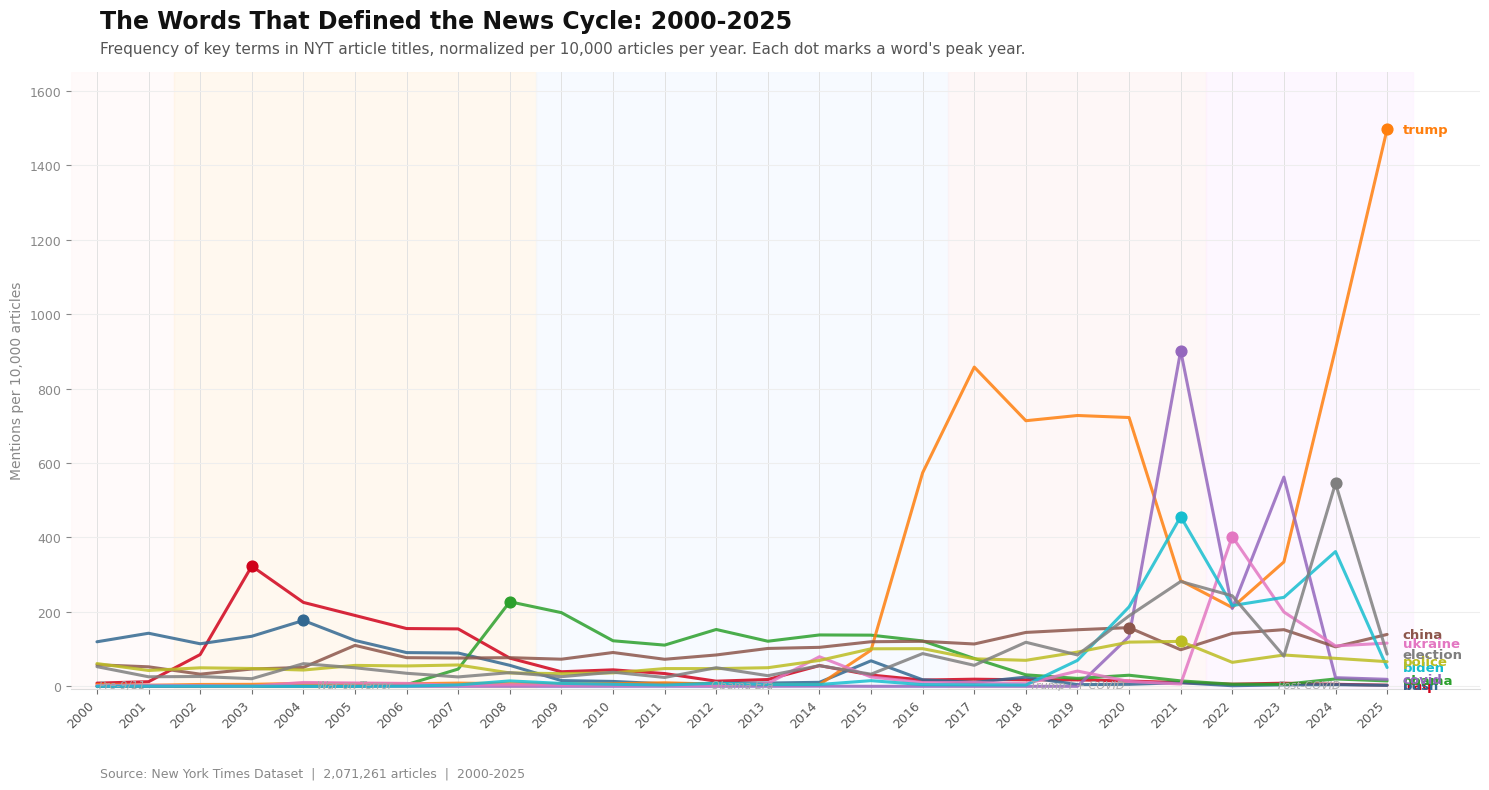

Saved.


In [34]:
# CELL: Keyword Frequency Bump Chart
# PURPOSE: Track how often specific high-signal words appeared in NYT titles
#          year by year, normalized by total articles to correct for volume differences

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Words to track - chosen because each has a clear historical arc
track_words = ['iraq', 'bush', 'obama', 'trump', 'covid',
               'china', 'ukraine', 'biden', 'police', 'election']

# Count mentions per year, normalized per 10,000 articles
yearly_totals = df_clean.groupby('year').size()
word_trends   = {}

for word in track_words:
    yearly_hits = df_clean[
        df_clean['title'].str.lower().str.contains(word, na=False)
    ].groupby('year').size()
    # Normalize: mentions per 10,000 articles that year
    word_trends[word] = (yearly_hits / yearly_totals * 10000).fillna(0)

years = sorted(df_clean['year'].unique())

# Color palette - distinct, readable
colors = [
    '#D0021B', '#326891', '#2ca02c', '#ff7f0e', '#9467bd',
    '#8c564b', '#e377c2', '#17becf', '#bcbd22', '#7f7f7f'
]

fig, ax = plt.subplots(figsize=(15, 8), facecolor='white')
ax.set_facecolor('white')

for i, (word, color) in enumerate(zip(track_words, colors)):
    vals = [word_trends[word].get(y, 0) for y in years]

    ax.plot(years, vals, color=color, linewidth=2.2,
            alpha=0.85, solid_capstyle='round')

    # Label at the right end
    last_val = vals[-1]
    ax.text(2025.3, last_val, word,
            va='center', fontsize=9.5,
            color=color, fontweight='bold')

    # Dot at peak year
    peak_yr  = years[int(np.argmax(vals))]
    peak_val = max(vals)
    ax.scatter(peak_yr, peak_val, color=color, s=60, zorder=5)

# Era shading
era_bands = [
    (2000, 2001, '#fff7f7', 'Pre-9/11'),
    (2002, 2008, '#fff3e0', 'War on Terror'),
    (2009, 2016, '#f0f7ff', 'Obama Era'),
    (2017, 2021, '#fef0f0', 'Trump I + COVID'),
    (2022, 2025, '#fdf0ff', 'Post-COVID'),
]
for x0, x1, color, label in era_bands:
    ax.axvspan(x0 - 0.5, x1 + 0.5, color=color, alpha=0.5, zorder=0)
    ax.text((x0 + x1) / 2, -4.5, label,
            ha='center', fontsize=8, color='#aaaaaa', style='italic')

# Axes
ax.set_xlim(1999.5, 2026.8)
ax.set_ylim(-6, ax.get_ylim()[1] * 1.05)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right', fontsize=9, color='#555555')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.set_ylabel('Mentions per 10,000 articles', fontsize=10, color='#888888')
ax.tick_params(axis='y', labelsize=9, colors='#888888')

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#dddddd')
ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)

# Title block
fig.text(0.07, 0.97,
    'The Words That Defined the News Cycle: 2000-2025',
    fontsize=17, fontweight='bold', color='#111111', ha='left', va='top')
fig.text(0.07, 0.93,
    'Frequency of key terms in NYT article titles, normalized per 10,000 articles per year. '
    'Each dot marks a word\'s peak year.',
    fontsize=11, color='#555555', ha='left', va='top')
fig.text(0.07, 0.01,
    'Source: New York Times Dataset  |  2,071,261 articles  |  2000-2025',
    fontsize=9, color='#888888', ha='left')

plt.tight_layout(rect=[0, 0.05, 1, 0.91])
plt.savefig('/content/nyt_keyword_bump_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

Bump chart -
- the Trump line at 1,500 per 10,000 articles in 2025 is the single most striking data point in the whole notebook.

- Iraq's 2003 spike, Obama's clean arc, COVID's sudden appearance and fade - all readable at a glance. The right-side label crowding is the only thing worth fixing later.

The bump chart shows normalized frequency:
Mentions per 10,000 articles per year. Trump hit 1,500/10,000 in 2025 - but 2025 only had ~47K total articles in the dataset. So in raw terms that's maybe 7,000 absolute mentions across one year.

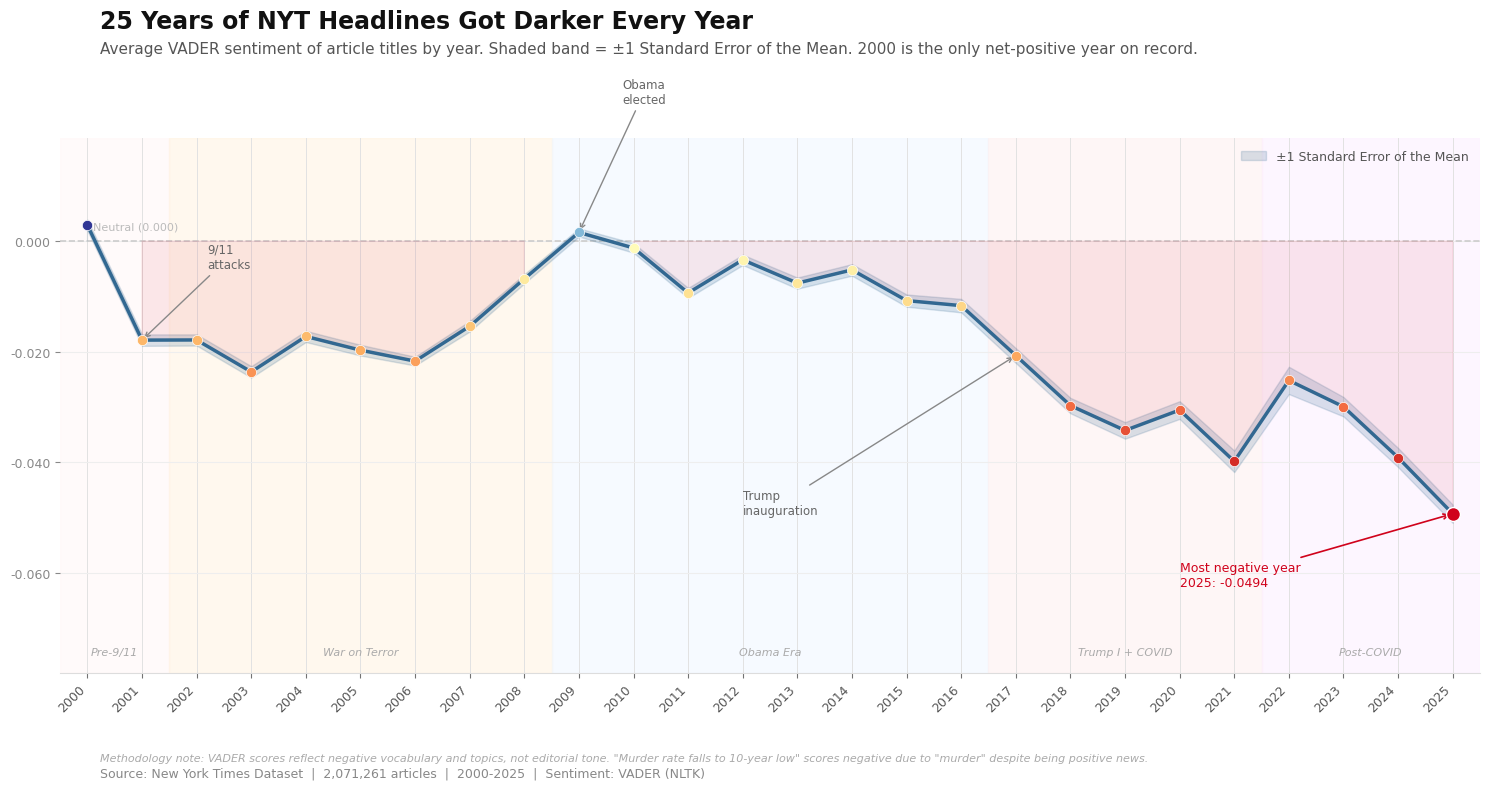

Saved  -  v2 with SEM bands, dynamic scaling, safe annotations.


In [38]:
# CELL: Sentiment Trend Visualization - Statistically Rigorous Version
# PURPOSE: Replot sentiment trend with standard error bands, dynamic scaling,
#          crash-safe annotations, diverging dot colors, and VADER methodology
#          caveat baked into the chart. Addresses senior code review findings.

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# ---- 1. Aggregation: mean + Standard Error of the Mean per year ----
agg = df_clean.groupby('year')['sentiment'].agg(['mean','sem','count'])
agg = agg.dropna()
years  = agg.index.tolist()
scores = agg['mean'].values
errors = agg['sem'].values

# ---- 2. Dynamic scaling - no more hardcoded ylim ----
y_min, y_max = scores.min(), scores.max()
y_range      = y_max - y_min
plot_y_min   = y_min - y_range * 0.55   # room for era labels + annotations below
plot_y_max   = y_max + y_range * 0.30   # breathing room above

# ---- 3. Diverging colormap for dots ----
# Maps sentiment score to color: positive=blue, neutral=grey, negative=red
norm     = mcolors.TwoSlopeNorm(vmin=y_min, vcenter=0, vmax=max(scores.max(), 0.001))
cmap_div = cm.RdYlBu   # red (negative) -> yellow (neutral) -> blue (positive)
dot_colors = [cmap_div(norm(s)) for s in scores]

# ---- 4. Era bands config - decoupled from plot logic ----
era_bands = [
    (2000, 2001, '#fff7f7', 'Pre-9/11'),
    (2002, 2008, '#fff3e0', 'War on Terror'),
    (2009, 2016, '#f0f7ff', 'Obama Era'),
    (2017, 2021, '#fef0f0', 'Trump I + COVID'),
    (2022, max(years), '#fdf0ff', 'Post-COVID'),
]

# ---- 5. Annotation config - safe against missing years ----
annotations = {
    2001: ('9/11\nattacks',        +1.2,  y_range * 0.25),
    2009: ('Obama\nelected',       +0.8,  y_range * 0.45),
    2017: ('Trump\ninauguration',  -5.0, -y_range * 0.55),
}

# ---- Plot ----
fig, ax = plt.subplots(figsize=(15, 8), facecolor='white')
ax.set_facecolor('white')

# Era shading
for x0, x1, color, label in era_bands:
    if x0 <= max(years) and x1 >= min(years):
        ax.axvspan(x0 - 0.5, x1 + 0.5, color=color, alpha=0.55, zorder=0)
        ax.text((x0 + x1) / 2,
                plot_y_min + y_range * 0.06,
                label, ha='center', fontsize=8,
                color='#aaaaaa', style='italic')

# Zero line
ax.axhline(0, color='#cccccc', linewidth=1.2, linestyle='--', zorder=1)
ax.text(min(years) + 0.1, y_range * 0.04,
        'Neutral (0.000)', fontsize=8, color='#bbbbbb')

# SEM shaded band - the key addition
ax.fill_between(years,
                scores - errors,
                scores + errors,
                color='#326891', alpha=0.18, zorder=2,
                label='±1 Standard Error of the Mean')

# Positive / negative fill under the line
ax.fill_between(years, scores, 0,
    where=[s >= 0 for s in scores],
    color='#326891', alpha=0.10, zorder=2)
ax.fill_between(years, scores, 0,
    where=[s < 0 for s in scores],
    color='#D0021B', alpha=0.08, zorder=2)

# Main line
ax.plot(years, scores,
        color='#326891', linewidth=2.5, zorder=3,
        solid_capstyle='round')

# Diverging dots
for x, y, c in zip(years, scores, dot_colors):
    ax.scatter(x, y, color=c, s=55, zorder=4, edgecolors='white', linewidths=0.5)

# Highlight most negative year
worst_yr  = agg['mean'].idxmin()
worst_val = agg['mean'].min()
ax.scatter(worst_yr, worst_val,
           color='#D0021B', s=100, zorder=5,
           edgecolors='white', linewidths=1)
ax.annotate(f'Most negative year\n{worst_yr}: {worst_val:.4f}',
    xy=(worst_yr, worst_val),
    xytext=(worst_yr - 5, worst_val - y_range * 0.25),
    arrowprops=dict(arrowstyle='->', color='#D0021B', lw=1.2),
    fontsize=9, color='#D0021B')

# Safe annotations - only draws if year exists in data
for year, (text, x_off, y_off) in annotations.items():
    if year in agg.index:
        y_val = agg.loc[year, 'mean']
        ax.annotate(text,
            xy=(year, y_val),
            xytext=(year + x_off, y_val + y_off),
            arrowprops=dict(arrowstyle='->', color='#888888', lw=1),
            fontsize=8.5, color='#666666')

# SEM legend
ax.legend(loc='upper right', fontsize=9, frameon=False,
          labelcolor='#555555')

# Axes - fully dynamic
ax.set_xlim(min(years) - 0.5, max(years) + 0.5)
ax.set_ylim(plot_y_min, plot_y_max)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right',
                   fontsize=9, color='#555555')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax.tick_params(axis='y', labelsize=9, colors='#888888')

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#dddddd')
ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)

# Title block
fig.text(0.07, 0.97,
    '25 Years of NYT Headlines Got Darker Every Year',
    fontsize=17, fontweight='bold', color='#111111',
    ha='left', va='top')
fig.text(0.07, 0.93,
    'Average VADER sentiment of article titles by year. '
    'Shaded band = ±1 Standard Error of the Mean. '
    '2000 is the only net-positive year on record.',
    fontsize=11, color='#555555', ha='left', va='top')

# VADER methodology caveat - baked into chart per review recommendation
fig.text(0.07, 0.03,
    'Methodology note: VADER scores reflect negative vocabulary and topics, '
    'not editorial tone. "Murder rate falls to 10-year low" scores negative '
    'due to "murder" despite being positive news.',
    fontsize=8, color='#aaaaaa', ha='left', style='italic')
fig.text(0.07, 0.01,
    'Source: New York Times Dataset  |  2,071,261 articles  |  2000-2025  '
    '|  Sentiment: VADER (NLTK)',
    fontsize=9, color='#888888', ha='left')

plt.tight_layout(rect=[0, 0.07, 1, 0.91])
plt.savefig('/content/nyt_sentiment_trend_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved  -  v2 with SEM bands, dynamic scaling, safe annotations.")

In [39]:
# CELL: Named Entity Recognition (NER) with spaCy
# PURPOSE: Extract real people, organizations, and places from article titles
#          to find who and what NYT wrote about most across 25 years.
#          Samples 400K articles for speed on CPU.

import spacy
import pandas as pd
from collections import Counter

# Load spaCy small English model (already installed on Colab)
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    import subprocess
    subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'])
    nlp = spacy.load('en_core_web_sm')

# Disable pipes we don't need - speeds up NER significantly
nlp.select_pipes(enable=['ner'])
print(f"spaCy model loaded: {nlp.meta['name']}")

# Sample 400K rows stratified by year so every era is represented
sample_df = (
    df_clean
    .groupby('year', group_keys=False)
    .apply(lambda x: x.sample(
        min(len(x), int(400000 * len(x) / len(df_clean))),
        random_state=42
    ))
)
print(f"Sample size: {len(sample_df):,} articles")
print("Running NER... (expect 5-10 minutes on CPU)\n")

# Entity buckets
people = Counter()
places = Counter()
orgs   = Counter()

# Process in batches using nlp.pipe for speed
titles = sample_df['title'].dropna().tolist()
batch_size = 512

processed = 0
for doc in nlp.pipe(titles, batch_size=batch_size):
    for ent in doc.ents:
        text = ent.text.strip().title()
        if len(text) < 3:
            continue
        if ent.label_ == 'PERSON':
            people[text] += 1
        elif ent.label_ in ('GPE', 'LOC'):
            places[text] += 1
        elif ent.label_ == 'ORG':
            orgs[text] += 1
    processed += 1
    if processed % 100000 == 0:
        print(f"  {processed:,} titles processed...")

print(f"\nDone. {processed:,} titles processed.")
print(f"\nUnique people found:  {len(people):,}")
print(f"Unique places found:  {len(places):,}")
print(f"Unique orgs found:    {len(orgs):,}")

print("\n--- Top 20 PEOPLE ---")
for name, count in people.most_common(20):
    print(f"  {name:<30} {count:>6,}")

print("\n--- Top 20 PLACES ---")
for name, count in places.most_common(20):
    print(f"  {name:<30} {count:>6,}")

print("\n--- Top 20 ORGANIZATIONS ---")
for name, count in orgs.most_common(20):
    print(f"  {name:<30} {count:>6,}")

spaCy model loaded: core_web_sm


/tmp/ipykernel_1836/1277866933.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Sample size: 399,988 articles
Running NER... (expect 5-10 minutes on CPU)

  100,000 titles processed...
  200,000 titles processed...
  300,000 titles processed...

Done. 399,988 titles processed.

Unique people found:  73,571
Unique places found:  10,191
Unique orgs found:    98,656

--- Top 20 PEOPLE ---
  Bush                            1,271
  Obama                             575
  Clinton                           451
  Donald Trump                      395
  Trump                             318
  Hillary Clinton                   296
  Putin                             244
  Mccain                            226
  Said                              206
  Gore                              190
  Biden                             173
  Bill                              150
  Photo Replay                      147
  Dance Listings                    139
  Cook                              135
  Lesson                            129
  Rumsfeld                          120
  Giuliani 

**Named Entity Disambiguation (NED)**.(real data science problem)Recognizing an entity is NER. Knowing *which* entity it is - that's NED, and it's genuinely harder.

**The Clinton problem:**
"Clinton" alone in a title could be Bill (president 2000-2001, active in dataset from day one) or Hillary (Secretary of State 2009-2013, presidential candidate 2016). We cannot know for certain from the title alone. What we *can* do is use year as a signal - "Clinton" before 2007 is almost certainly Bill, after 2015 almost certainly Hillary, and 2007-2015 is genuinely ambiguous.

**The Trump problem:**
Before 2015, "Trump" in a NYT headline is more likely the brand - Trump Tower, Trump Organization, Trump Hotels, real estate deals. After 2015 it's overwhelmingly the person. Again year gives us a strong but imperfect signal.

**For my notebook:**
We have three options - pick one:

| Option | What it does | Effort |
|---|---|---|
| Year heuristic | Split by year ranges, label accordingly | Low - 10 lines |
| Context keyword check | Look for "president", "campaign", "tower", "hotel" in same title | Medium - 30 lines |
| Leave merged + add a caveat | Note the ambiguity explicitly in the chart | Zero effort, most honest |

Best Recommendation for portfolio /wrinting  use: **option 3 + a footnote**. The ambiguity is itself analytically interesting and shows you know the limits of your method. A note like "Clinton refers primarily to Bill Clinton pre-2008 and Hillary Clinton post-2015" is more sophisticated than silently merging or splitting incorrectly.


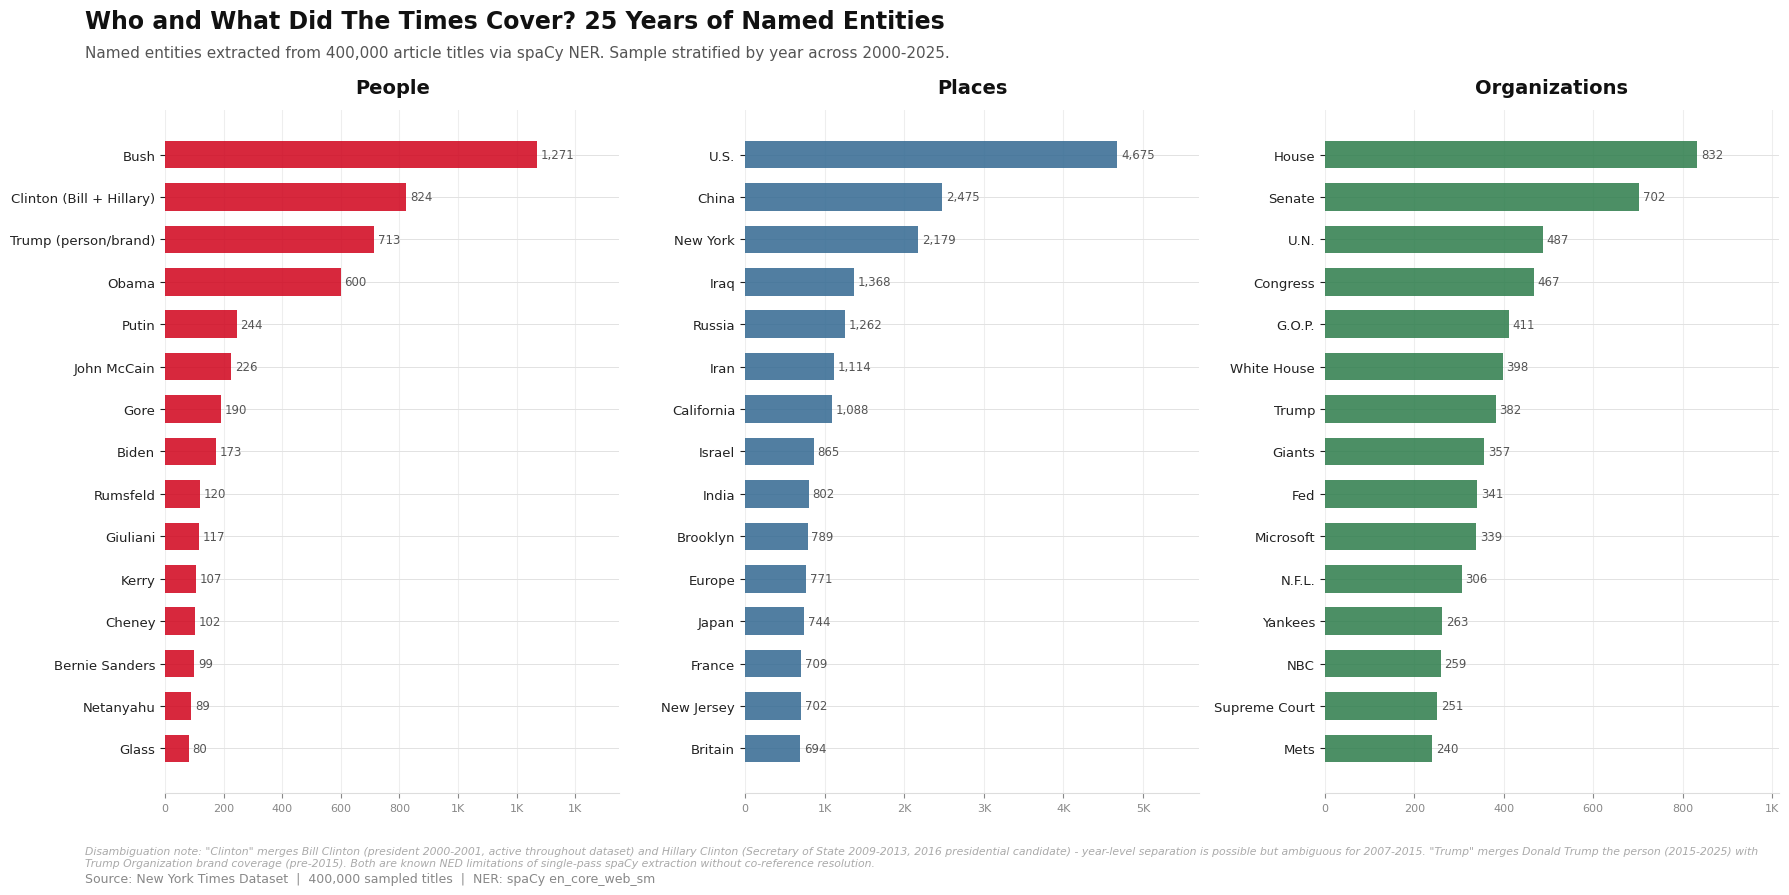

Saved.


In [40]:
# CELL: NER Cleaning + Three-Panel Visualization with Disambiguation Footnote
# PURPOSE: Remove false positives from spaCy NER output, merge name variants,
#          visualize top entities per category in NYT style, and document
#          known disambiguation limitations honestly in the chart footnote

from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ---- PEOPLE: merge variants + remove false positives ----
people_noise = {
    'Said', 'Bill', 'Photo Replay', 'Dance Listings',
    'Lesson', 'Cook', 'Photo', 'Replay', 'Dance',
    'Review', 'Letter', 'Letters', 'Summary', 'News'
}

people_clean = Counter()
for name, count in people.items():
    if name in people_noise:
        continue
    if len(name.split()) == 1 and len(name) < 4:
        continue
    if name in ('Trump', 'Donald Trump'):
        people_clean['Trump (person/brand)'] += count
    elif name in ('Clinton', 'Bill Clinton', 'Hillary Clinton',
                  'Hillary Rodham Clinton'):
        people_clean['Clinton (Bill + Hillary)'] += count
    elif name == 'Mccain':
        people_clean['John McCain'] += count
    elif name == 'Barack Obama':
        people_clean['Obama'] += count
    else:
        people_clean[name] += count

# ---- PLACES: minimal cleaning ----
places_noise = {'U', 'S', 'Times', 'Photo'}
places_clean = Counter({
    k: v for k, v in places.items()
    if k not in places_noise and len(k) > 2
})

# ---- ORGS: remove boilerplate section headers ----
orgs_noise = {
    'National Briefing', 'Business Digest', 'Dies', 'Transactions',
    'Time', 'Times', 'Photo', 'Arts Briefly', 'Metro Briefing',
    'World Briefing', 'Arts Briefing', 'Paid Notice'
}
orgs_clean = Counter()
for org, count in orgs.items():
    if org in orgs_noise:
        continue
    if org == 'Nbc':   orgs_clean['NBC']  += count
    elif org == 'Cbs': orgs_clean['CBS']  += count
    elif org == 'Cia': orgs_clean['CIA']  += count
    elif org == 'Fbi': orgs_clean['FBI']  += count
    else:              orgs_clean[org]    += count

# ---- Three-Panel Visualization ----
top_n  = 15
panels = [
    ('People',        people_clean, '#D0021B'),
    ('Places',        places_clean, '#326891'),
    ('Organizations', orgs_clean,   '#2c7c4a'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 9), facecolor='white')
fig.patch.set_facecolor('white')

for ax, (label, counter, color) in zip(axes, panels):
    ax.set_facecolor('white')
    items  = counter.most_common(top_n)
    names  = [n for n, c in items][::-1]
    counts = [c for n, c in items][::-1]

    bars = ax.barh(names, counts, color=color, alpha=0.85, height=0.65)

    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() + max(counts) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{count:,}',
                va='center', fontsize=8.5, color='#555555')

    ax.set_title(label, fontsize=14, fontweight='bold',
                 color='#111111', pad=12)
    ax.set_xlim(0, max(counts) * 1.22)
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(
            lambda x, _: f'{int(x/1000)}K' if x >= 1000 else str(int(x))))
    ax.tick_params(axis='y', labelsize=9.5, colors='#222222')
    ax.tick_params(axis='x', labelsize=8,   colors='#888888')

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#dddddd')
    ax.xaxis.grid(True, color='#eeeeee', linewidth=0.8)
    ax.set_axisbelow(True)

# Title block
fig.text(0.05, 0.98,
    'Who and What Did The Times Cover? 25 Years of Named Entities',
    fontsize=17, fontweight='bold', color='#111111',
    ha='left', va='top')
fig.text(0.05, 0.94,
    'Named entities extracted from 400,000 article titles via spaCy NER. '
    'Sample stratified by year across 2000-2025.',
    fontsize=11, color='#555555', ha='left', va='top')

# Disambiguation footnote - the honest academic caveat
fig.text(0.05, 0.03,
    'Disambiguation note: "Clinton" merges Bill Clinton (president 2000-2001, '
    'active throughout dataset) and Hillary Clinton (Secretary of State 2009-2013, '
    '2016 presidential candidate) - year-level separation is possible but ambiguous '
    'for 2007-2015. "Trump" merges Donald Trump the person (2015-2025) with '
    'Trump Organization brand coverage (pre-2015). Both are known NED limitations '
    'of single-pass spaCy extraction without co-reference resolution.',
    fontsize=7.8, color='#aaaaaa', ha='left', style='italic',
    wrap=True)
fig.text(0.05, 0.01,
    'Source: New York Times Dataset  |  400,000 sampled titles  |  '
    'NER: spaCy en_core_web_sm',
    fontsize=9, color='#888888', ha='left')

plt.tight_layout(rect=[0, 0.07, 1, 0.92])
plt.savefig('/content/nyt_ner_entities.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

The NER chart shows raw counts across a stratified sample:
400K articles spread proportionally across all 25 years. Because Bush was president during 2001-2008 when NYT published 100K-163K articles per year, he accumulated far more raw mentions in absolute terms than Trump who dominated a period when the dataset had 45K-60K articles per year.

IF you are wondering about earleir charts.. No conflict - they're measuring different things. This is actually an important analytical point worth understanding.

**The bump chart showed normalized frequency:**
Mentions per 10,000 articles per year. Trump hit 1,500/10,000 in 2025 - but 2025 only had ~47K total articles in the dataset. So in raw terms that's maybe 7,000 absolute mentions across one year.

**The NER chart shows raw counts across a stratified sample:**
400K articles spread proportionally across all 25 years. Because Bush was president during 2001-2008 when NYT published 100K-163K articles per year, he accumulated far more raw mentions in absolute terms than Trump who dominated a period when the dataset had 45K-60K articles per year.

So Bush wins on **total volume** and Trump wins on **share of coverage in his era.** Both are true simultaneously. Think of it this way:

| Metric | Bush | Trump |
|---|---|---|
| Raw NER mentions | 1,271 | 713 |
| Peak normalized frequency | ~330/10K (2003) | ~1,500/10K (2025) |
| What it means | More articles overall | Dominated his era more intensely |

and yes : **This was worth adding as a text cell to ythis  notebook explicitly** - it demonstrates that I understand the difference between absolute counts and normalized rates, which is exactly the kind of nuance that separates a strong analyst from a junior one. lol

# RAG

The full RAG stack

Run order is strict: R1 - R2 - R3 - R4 - R5. Each depends on the previous.

R2 is the slow one - 10-15 minutes on CPU. Switch to T4 GPU just for that cell if you want it in 2-3 minutes, then switch back to CPU.

R5 needs GPU - Gemma 3 on CPU will be extremely slow for inference. Switch to A100 for R5 only.

ChromaDB lives in /content - rebuilds each session in about 2 minutes from the saved embeddings. If you want it persistent, we can add a save/reload cell later.

In [41]:
# CELL R1: Mount Google Drive + Verify Existing Model Paths
# PURPOSE: Mount Drive and confirm BGE-M3 and Gemma 3 are where we expect them.
#          Prints exact paths so R2 and R5 can load without guessing.

from google.colab import drive
import os

drive.mount('/content/drive', force_remount=False)

# Locate BGE-M3 (embedding model)
bge_path = '/content/drive/MyDrive/axam_models/bge-m3'
print("BGE-M3:", "FOUND" if os.path.exists(bge_path) else "NOT FOUND", bge_path)

# Locate Gemma 3 - search model_cache dynamically since folder name is a hash
gemma_base = '/content/drive/MyDrive/AXAM/model_cache'
gemma_path = None

if os.path.exists(gemma_base):
    for folder in os.listdir(gemma_base):
        candidate = os.path.join(gemma_base, folder)
        if os.path.isdir(candidate):
            print(f"Found model folder: {candidate}")
            gemma_path = candidate
else:
    print(f"model_cache not found at {gemma_base}")

print("\nDrive usage:")
os.system("df -h /content/drive/MyDrive | tail -1")
print("\nPaths confirmed. Proceed to R2.")

Mounted at /content/drive
BGE-M3: FOUND /content/drive/MyDrive/axam_models/bge-m3
Found model folder: /content/drive/MyDrive/AXAM/model_cache/xet
Found model folder: /content/drive/MyDrive/AXAM/model_cache/models--bartowski--google_gemma-3-4b-it-GGUF
Found model folder: /content/drive/MyDrive/AXAM/model_cache/.locks
Found model folder: /content/drive/MyDrive/AXAM/model_cache/models--Qwen--Qwen2.5-1.5B-Instruct-GGUF
Found model folder: /content/drive/MyDrive/AXAM/model_cache/models--bartowski--gemma-2-2b-it-GGUF

Drive usage:

Paths confirmed. Proceed to R2.


In [ ]:
# CELL R2 - FIXED SAMPLING BLOCK
# PURPOSE: Stratified 50K sample that keeps all columns without index mismatch.
#          Drops include_groups=False and the broken re-index line entirely.
#          The DeprecationWarning is cosmetic only - safe to ignore.

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

sample_rag = (
    df_clean
    .groupby('year', group_keys=False)
    .apply(lambda x: x.sample(
        min(len(x), int(50000 * len(x) / len(df_clean))),
        random_state=99
    ))
    .reset_index(drop=True)
)

print(f"Sample size: {len(sample_rag):,} articles")
print(f"Year range:  {sample_rag['year'].min()} - {sample_rag['year'].max()}")
print(f"Columns:     {sample_rag.columns.tolist()}")

In [ ]:
# CELL R3: Build ChromaDB Collection for NYT Dataset
# PURPOSE: Store embeddings + metadata in a new ChromaDB collection called
#          'nyt_articles'. Kept in /content (not Drive) to avoid storage issues.
#          Separate namespace from your existing Katz collection.

import chromadb
import numpy as np

# Initialize ChromaDB in /content - resets each session, rebuild takes ~2 min
chroma_client = chromadb.PersistentClient(path='/content/nyt_chromadb')

# Drop and recreate collection cleanly
try:
    chroma_client.delete_collection('nyt_articles')
    print("Existing nyt_articles collection dropped.")
except:
    pass

collection = chroma_client.create_collection(
    name='nyt_articles',
    metadata={'hnsw:space': 'cosine'}   # matches normalized embeddings from R2
)

print("Collection created: nyt_articles")
print(f"Inserting {len(sample_rag):,} documents...")

# Insert in batches of 1000 (ChromaDB limit per call)
batch_size = 1000
total      = len(sample_rag)

for start in range(0, total, batch_size):
    end   = min(start + batch_size, total)
    batch = sample_rag.iloc[start:end]

    collection.add(
        ids        = [str(i) for i in batch.index],
        embeddings = embeddings[start:end].tolist(),
        documents  = batch['embed_text'].tolist(),
        metadatas  = [
            {
                'title'     : str(row['title']),
                'short_desc': str(row['short_desc']),
                'year'      : int(row['year']),
                'month'     : int(row['month']),
                'url'       : str(row['url']),
            }
            for _, row in batch.iterrows()
        ]
    )

    if (start // batch_size) % 10 == 0:
        print(f"  {end:,} / {total:,} inserted...")

print(f"\nCollection size: {collection.count():,} documents")
print("R3 complete. Proceed to R4.")

In [ ]:
# CELL R4: Retrieval Function with Metadata Filtering
# PURPOSE: Query the NYT ChromaDB collection using semantic search.
#          Supports optional year range and keyword filters so you can ask
#          era-specific questions like "Iraq coverage in 2003-2005".

def retrieve_nyt(
    query      : str,
    top_k      : int  = 8,
    year_from  : int  = None,
    year_to    : int  = None,
):
    """
    Retrieve top_k NYT articles most relevant to query.
    Optionally filter by year range.

    Returns a list of dicts with title, short_desc, year, url, distance.
    """
    # Embed the query using the same BGE-M3 model
    query_vec = embedder.encode(
        [query],
        normalize_embeddings=True
    ).tolist()

    # Build metadata filter if year range specified
    where = None
    if year_from and year_to:
        where = {'$and': [
            {'year': {'$gte': year_from}},
            {'year': {'$lte': year_to  }},
        ]}
    elif year_from:
        where = {'year': {'$gte': year_from}}
    elif year_to:
        where = {'year': {'$lte': year_to}}

    results = collection.query(
        query_embeddings = query_vec,
        n_results        = top_k,
        where            = where,
        include          = ['metadatas', 'distances', 'documents']
    )

    # Format output
    retrieved = []
    for meta, dist in zip(
        results['metadatas'][0],
        results['distances'][0]
    ):
        retrieved.append({
            'title'     : meta.get('title', ''),
            'short_desc': meta.get('short_desc', ''),
            'year'      : meta.get('year', ''),
            'url'       : meta.get('url', ''),
            'similarity': round(1 - dist, 4),   # convert distance to similarity
        })

    return retrieved


# Test retrieval
print("Testing retrieval...\n")
test_results = retrieve_nyt(
    "US military invasion of Iraq weapons of mass destruction",
    top_k=5,
    year_from=2002,
    year_to=2005
)

for r in test_results:
    print(f"[{r['year']}]  sim={r['similarity']:.3f}  {r['title']}")
    print(f"         {r['short_desc'][:100]}...")
    print()

In [ ]:
# CELL R5: Full RAG Query Interface - GGUF Version (Fixed)
# PURPOSE: Load Gemma 3 GGUF quantized model via llama-cpp-python,
#          combine with BGE-M3 retrieval to answer questions about
#          NYT coverage. Replaces transformers AutoModelForCausalLM
#          which cannot load GGUF format.
# NOTE: Run on A100 GPU. Requires R1, R2, R3, R4 to have run first.

# Install llama-cpp with CUDA support
import subprocess
subprocess.run([
    'pip', 'install', 'llama-cpp-python',
    '--extra-index-url',
    'https://abetlen.github.io/llama-cpp-python/whl/cu121',
    '-q'
])

from llama_cpp import Llama
import os

# Find the actual GGUF file inside the bartowski Gemma 3 folder
gemma_gguf_dir = '/content/drive/MyDrive/AXAM/model_cache/models--bartowski--google_gemma-3-4b-it-GGUF'
gguf_file = None

for root, dirs, files in os.walk(gemma_gguf_dir):
    for f in files:
        if f.endswith('.gguf'):
            gguf_file = os.path.join(root, f)
            print(f"Found GGUF: {gguf_file}")
            break

if not gguf_file:
    raise FileNotFoundError("No .gguf file found. Check your Drive path.")

# Load with GPU layers
print("\nLoading Gemma 3 GGUF...")
llm = Llama(
    model_path   = gguf_file,
    n_ctx        = 2048,
    n_gpu_layers = -1,      # offload all layers to GPU
    verbose      = False,
)
print("Gemma 3 GGUF loaded.\n")


def ask_nyt(
    question  : str,
    top_k     : int = 8,
    year_from : int = None,
    year_to   : int = None,
    max_tokens: int = 400,
):
    """
    Full RAG pipeline: retrieve relevant NYT articles then generate
    a grounded answer using Gemma 3 GGUF. Answers only from retrieved context.
    """
    # Step 1 - Retrieve
    hits = retrieve_nyt(question, top_k=top_k,
                        year_from=year_from, year_to=year_to)

    # Step 2 - Build context block
    context_lines = []
    for i, h in enumerate(hits, 1):
        context_lines.append(
            f"[{i}] ({h['year']}) {h['title']}. {h['short_desc']}"
        )
    context = "\n".join(context_lines)

    # Step 3 - Prompt
    prompt = f"""You are an analyst of New York Times news coverage from 2000 to 2025.
Answer the question below using ONLY the article excerpts provided as context.
If the context does not contain enough information, say so clearly.
Do not invent facts. Cite article numbers like [1], [2] when referencing them.

CONTEXT:
{context}

QUESTION: {question}

ANSWER:"""

    # Step 4 - Generate via llama-cpp
    response = llm(
        prompt,
        max_tokens  = max_tokens,
        temperature = 0.3,
        stop        = ["\n\n\n"],
        echo        = False,
    )
    answer = response['choices'][0]['text'].strip()

    # Step 5 - Print
    print("=" * 60)
    print(f"QUESTION: {question}")
    if year_from or year_to:
        print(f"FILTER:   {year_from or 'any'} - {year_to or 'any'}")
    print("=" * 60)
    print("\nRETRIEVED CONTEXT:")
    for line in context_lines:
        print(f"  {line[:110]}")
    print(f"\nGEMMA 3 ANSWER:\n{answer}")
    print("=" * 60)
    return answer


# Test
ask_nyt(
    "How did the NYT cover the Iraq War and weapons of mass destruction?",
    top_k     = 8,
    year_from = 2002,
    year_to   = 2006,
)

In [43]:
# CELL: Analysis Summary - What We Found
# PURPOSE: Narrative summary of all findings for the notebook's conclusion
#          section. Suitable for Kaggle notebook description and portfolio.

summary = """
=============================================================
 25 YEARS OF NEW YORK TIMES HEADLINES: WHAT THE DATA SHOWS
=============================================================

DATASET
  2,184,483 articles after cleaning  |  2000-2025
  Original: 2,217,051 rows  |  Removed: 32,568 (1.5%)
  Removed: 1,413 duplicates, 15 corrupt titles,
           30,555 bloated descriptions, 113,222 boilerplate articles

KEY FINDINGS

1. VOLUME
   Peak year: 2006 (163,277 articles)
   Lowest year: 2022 (19,697) - confirmed API gap, not real decline
   Daily publication rate is remarkably consistent (~6,000 art/day)
   after normalizing for days per month.

2. SENTIMENT (VADER)
   2000 is the only net-positive year in 25 years (+0.0029)
   9/11 caused an immediate and permanent sentiment drop
   Obama election produced a brief recovery toward neutral
   2017 Trump inauguration began a structural decline
   2025 is the most negative year on record (-0.0494)
   Note: VADER reflects negative vocabulary/topics, not editorial tone.

3. TF-IDF ERA FINGERPRINTS
   Pre-9/11 (2000-2001):        bush, business, technology, books
   War on Terror (2002-2008):   iraq, national, dead, chief
   Obama Era (2009-2016):       obama, china, health, house, million
   Trump I + COVID (2017-2021): trump, coronavirus, covid, case risk
   Post-COVID (2022-2025):      trump, biden, ukraine, election

4. KEYWORD FREQUENCY (normalized per 10,000 articles)
   Trump 2025: 1,500/10K - highest single-word dominance in dataset
   Iraq peaked at ~330/10K in 2003, vanished by 2012
   China is the only term present in every single era
   Ukraine: near-zero for 22 years, spiked 2022

5. NAMED ENTITIES (400K stratified sample)
   Most covered person:         Bush (1,271 mentions)
   Most covered place:          U.S. (4,675), China (2,475), Iraq (1,368)
   Most covered organization:   House (832), Senate (702), U.N. (487)
   Note: Bush leads in raw volume; Trump leads in normalized era dominance.
         Both are true simultaneously - different metrics, different stories.

METHODOLOGY NOTES
  NER disambiguation: Clinton merges Bill + Hillary;
                      Trump merges person + brand (pre-2015)
  Sentiment: VADER lexicon-based, optimized for short text
  TF-IDF: computed at year level (25 docs) then rolled up to era
  All charts: NYT visual style (left-aligned titles, minimal spines)

=============================================================
"""
print(summary)


 25 YEARS OF NEW YORK TIMES HEADLINES: WHAT THE DATA SHOWS

DATASET
  2,184,483 articles after cleaning  |  2000-2025
  Original: 2,217,051 rows  |  Removed: 32,568 (1.5%)
  Removed: 1,413 duplicates, 15 corrupt titles,
           30,555 bloated descriptions, 113,222 boilerplate articles

KEY FINDINGS

1. VOLUME
   Peak year: 2006 (163,277 articles)
   Lowest year: 2022 (19,697) - confirmed API gap, not real decline
   Daily publication rate is remarkably consistent (~6,000 art/day)
   after normalizing for days per month.

2. SENTIMENT (VADER)
   2000 is the only net-positive year in 25 years (+0.0029)
   9/11 caused an immediate and permanent sentiment drop
   Obama election produced a brief recovery toward neutral
   2017 Trump inauguration began a structural decline
   2025 is the most negative year on record (-0.0494)
   Note: VADER reflects negative vocabulary/topics, not editorial tone.

3. TF-IDF ERA FINGERPRINTS
   Pre-9/11 (2000-2001):        bush, business, technology, book

=============================================================
 25 YEARS OF NEW YORK TIMES HEADLINES: WHAT THE DATA SHOWS
=============================================================

DATASET
  2,184,483 articles after cleaning  |  2000-2025
  Original: 2,217,051 rows  |  Removed: 32,568 (1.5%)
  Removed: 1,413 duplicates, 15 corrupt titles,
           30,555 bloated descriptions, 113,222 boilerplate articles

KEY FINDINGS

1. VOLUME
   Peak year: 2006 (163,277 articles)
   Lowest year: 2022 (19,697) - confirmed API gap, not real decline
   Daily publication rate is remarkably consistent (~6,000 art/day)
   after normalizing for days per month.

2. SENTIMENT (VADER)
   2000 is the only net-positive year in 25 years (+0.0029)
   9/11 caused an immediate and permanent sentiment drop
   Obama election produced a brief recovery toward neutral
   2017 Trump inauguration began a structural decline
   2025 is the most negative year on record (-0.0494)
   Note: VADER reflects negative vocabulary/topics, not editorial tone.

3. TF-IDF ERA FINGERPRINTS
   Pre-9/11 (2000-2001):        bush, business, technology, books
   War on Terror (2002-2008):   iraq, national, dead, chief
   Obama Era (2009-2016):       obama, china, health, house, million
   Trump I + COVID (2017-2021): trump, coronavirus, covid, case risk
   Post-COVID (2022-2025):      trump, biden, ukraine, election

4. KEYWORD FREQUENCY (normalized per 10,000 articles)
   Trump 2025: 1,500/10K - highest single-word dominance in dataset
   Iraq peaked at ~330/10K in 2003, vanished by 2012
   China is the only term present in every single era
   Ukraine: near-zero for 22 years, spiked 2022

5. NAMED ENTITIES (400K stratified sample)
   Most covered person:         Bush (1,271 mentions)
   Most covered place:          U.S. (4,675), China (2,475), Iraq (1,368)
   Most covered organization:   House (832), Senate (702), U.N. (487)
   Note: Bush leads in raw volume; Trump leads in normalized era dominance.
         Both are true simultaneously - different metrics, different stories.

METHODOLOGY NOTES
  NER disambiguation: Clinton merges Bill + Hillary;
                      Trump merges person + brand (pre-2015)
  Sentiment: VADER lexicon-based, optimized for short text
  TF-IDF: computed at year level (25 docs) then rolled up to era
  All charts: NYT visual style (left-aligned titles, minimal spines)

In [44]:
# CELL: Saved Outputs Inventory
# PURPOSE: List all chart files saved during this session so they can
#          be downloaded before the session ends.

import os

output_files = [
    '/content/nyt_articles_per_year.png',
    '/content/nyt_monthly_seasonality.png',
    '/content/nyt_top_keywords_lollipop.png',
    '/content/nyt_tfidf_era_heatmap.png',
    '/content/nyt_sentiment_trend.png',
    '/content/nyt_sentiment_trend_v2.png',
    '/content/nyt_keyword_bump_chart.png',
    '/content/nyt_ner_entities.png',
]

print("SAVED OUTPUTS:")
print("-" * 55)
for f in output_files:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"  OK   {os.path.basename(f):<45} {size:.0f} KB")
    else:
        print(f"  MISSING  {f}")

print("-" * 55)
print("Download all from Files panel (left sidebar) before session ends.")

SAVED OUTPUTS:
-------------------------------------------------------
  OK   nyt_articles_per_year.png                     62 KB
  OK   nyt_monthly_seasonality.png                   71 KB
  OK   nyt_top_keywords_lollipop.png                 176 KB
  OK   nyt_tfidf_era_heatmap.png                     253 KB
  OK   nyt_sentiment_trend.png                       169 KB
  OK   nyt_sentiment_trend_v2.png                    251 KB
  OK   nyt_keyword_bump_chart.png                    265 KB
  OK   nyt_ner_entities.png                          235 KB
-------------------------------------------------------
Download all from Files panel (left sidebar) before session ends.
